#### Chapter 09-1. 순차데이터와 순화 신경망

🔥순차 데이터 sequential data

In [ ]:
#순차 데이터는 텍스트나 시계열 데이터 time series data와 같이 순서에 의미가 있는 데이터를 말함
#🍍순차 데이터를 다룰 때는 이전에 입력한 데이터를 기억하는 기능이 필요
#   완전 연결 신경망이나 합성곱 신경망은 이런 기억 장치가 없음
#   하나의 샘플（또는 하나의 배치을 사용하여 정방향 계산을 수행하고 나면 
#   그 샘플은 버려지고 다음 샘플을 처리할 때 재사용하지 않음

#🍍입력 데이터의 흐름이 앞으로만 전달되는 신경망을 피드포워드 신경망feedforward neural network. 

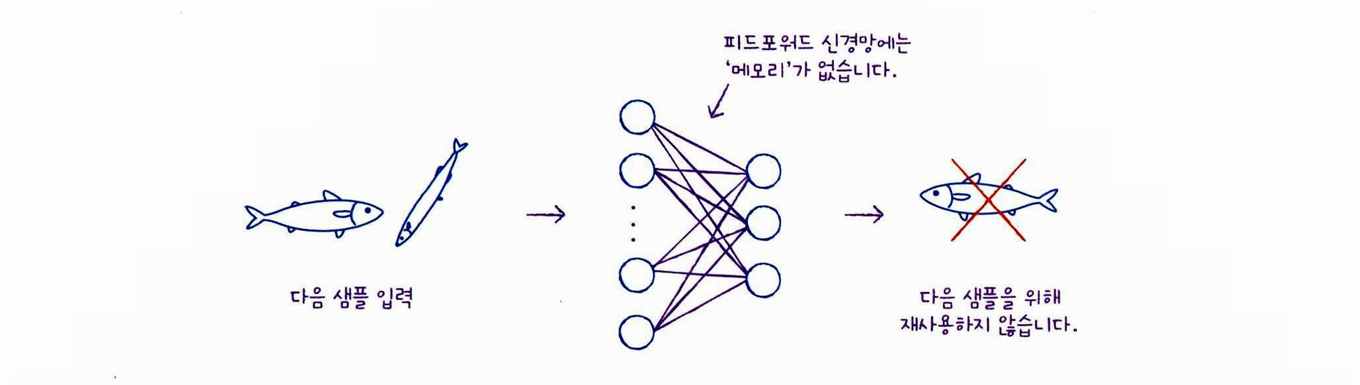
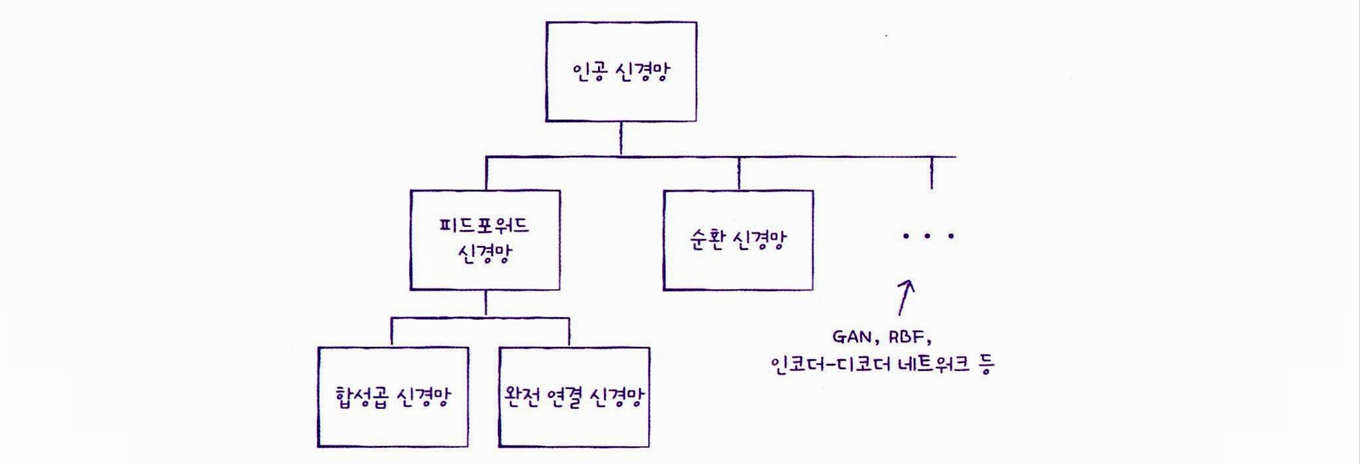

🔥순환 신경망 recurrent neural network, RNN

In [ ]:
#완전 연결 신경망에 이전 데이터의 처리 결과가 순환되는 고리 하나만 추가
#은닉층에 있는 붉은 고리

#뉴런의 출력이 다시 자기 자신으로 전달
#어떤 샘플을 처리 할 때 바로 이전에 사용했던 데이터를 재사용하는 셈

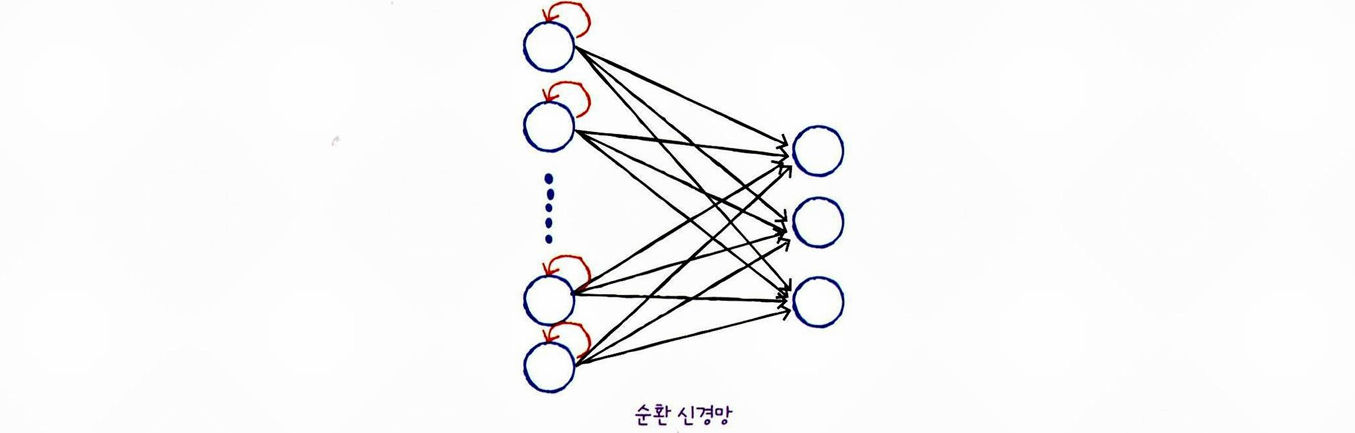

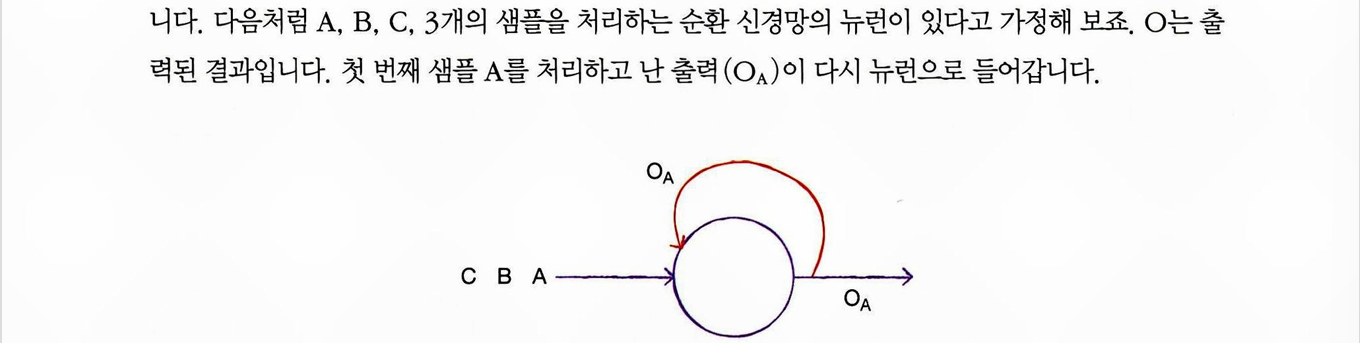
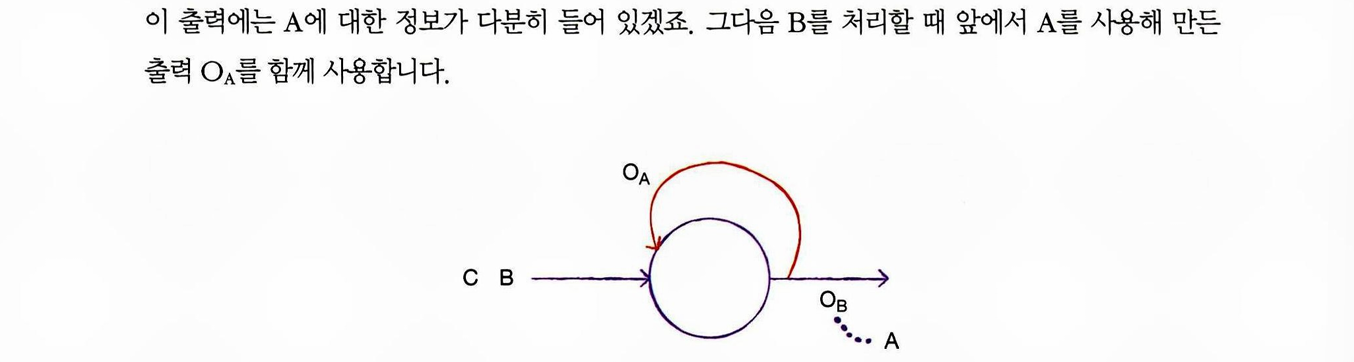
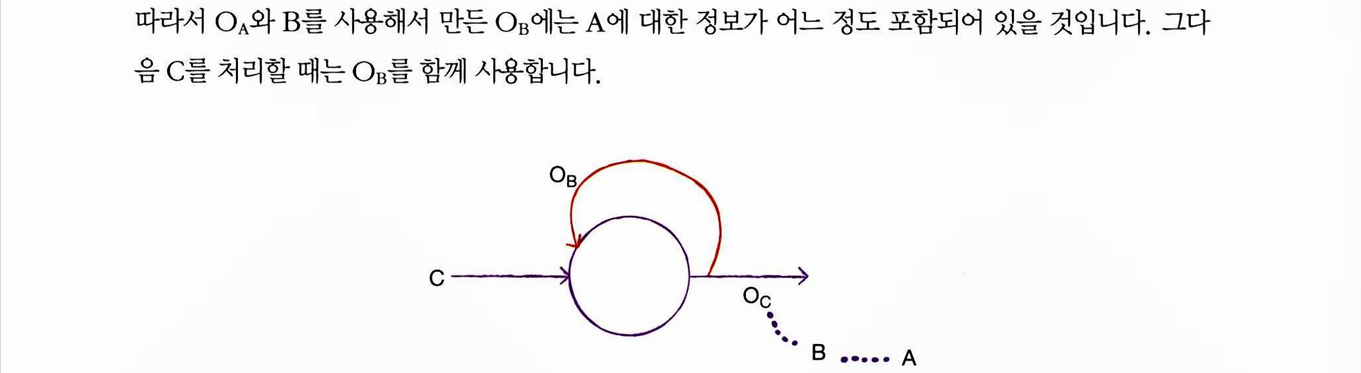

In [ ]:
# 샘플을 처리하는 한 단계를 타임스텝 timestep 이라고 말함
# Oc에는 A에 대한 정보보다는 B에 대한 정보가 더 많을 것
# 순환 신경망은 이전 타임 스텝의 샘플을 기억하지만 타임스텝이 오래될수록 순환되는 정보는 희미해짐

# 순환 신경망에서는 특별히 층을 셀cell 이라고 부름
# 셀의 출력을 은닉 상태 hidden state라고 부름

# 입력에 어떤 가중치를 곱하고 활성화 함수를 통과시켜 다음 층으로 보낸다
# 달라지는 것은 층의 출력（즉 은닉 상태）을 다음 타임 스텝에 재사용한다

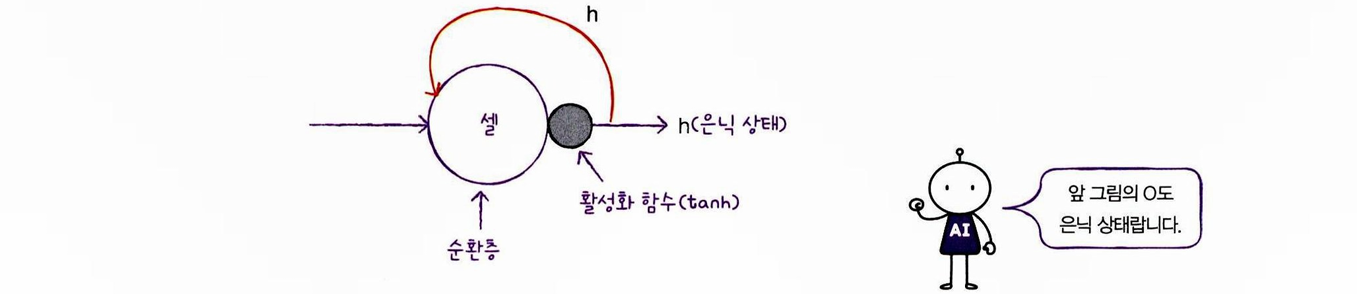

In [ ]:
# 은닉층의 활성화 함수로는 하이퍼볼릭 탄젠트hyperbolic tangent 함수인 tanh가 많이 사용
# tanh 함수도 S자 모양을 띠기 때문에 종종 시그모이드 함수라고 부름

# tanh 함수는 시그모이드 함수와는 달리 -1〜1 사이의 범위를 가짐

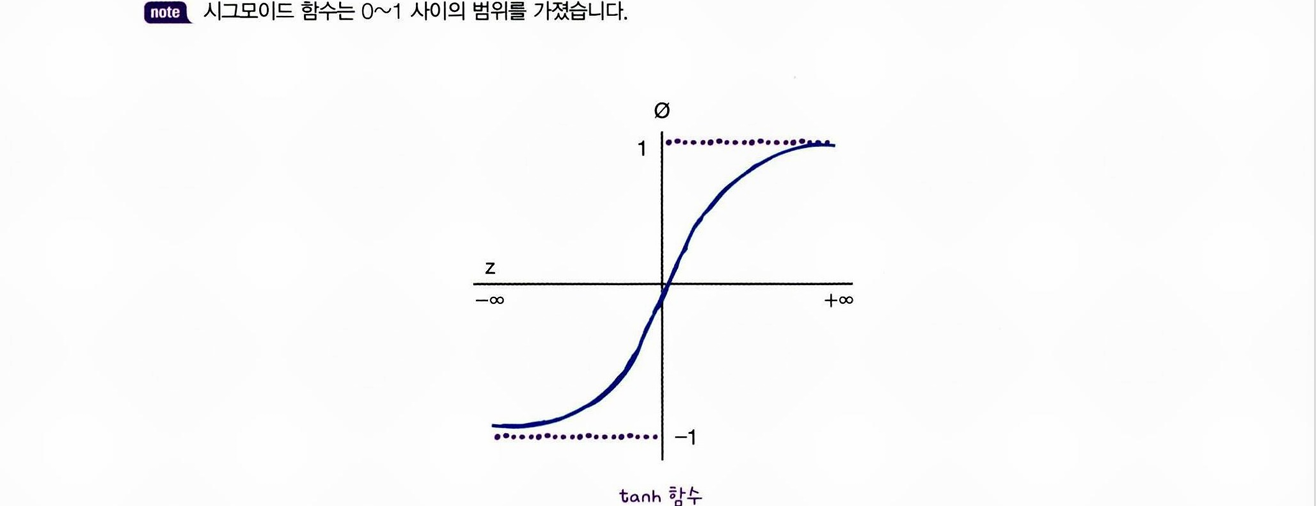

In [ ]:
# 합성곱 신경망과 같은 피드포워드 신경망에서 뉴런은 입력과 가중치를 곱한다.
# 순환 신경망에서도 동일 다만 순환 신경망의 뉴런은 가중치가 하나 더 있다. 
# 바로 이전 타임스텝의 은닉 상태에 곱해지는 가중치!
# 셀은 입력과 이전 타임스텝의 은닉 상태를 사용하여 현재 타임스텝의 은닉 상태를 만든다.

In [ ]:
# Wx는 입력에 곱해지는 가중치이고 Wb는 이전 타임스텝의 은닉 상태에 곱해지는 가중치

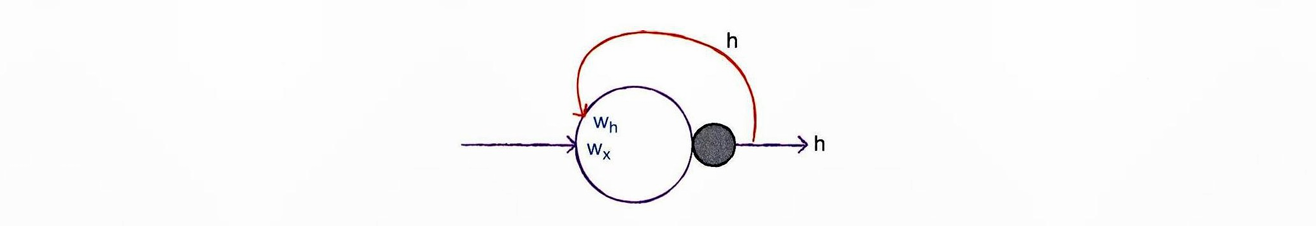


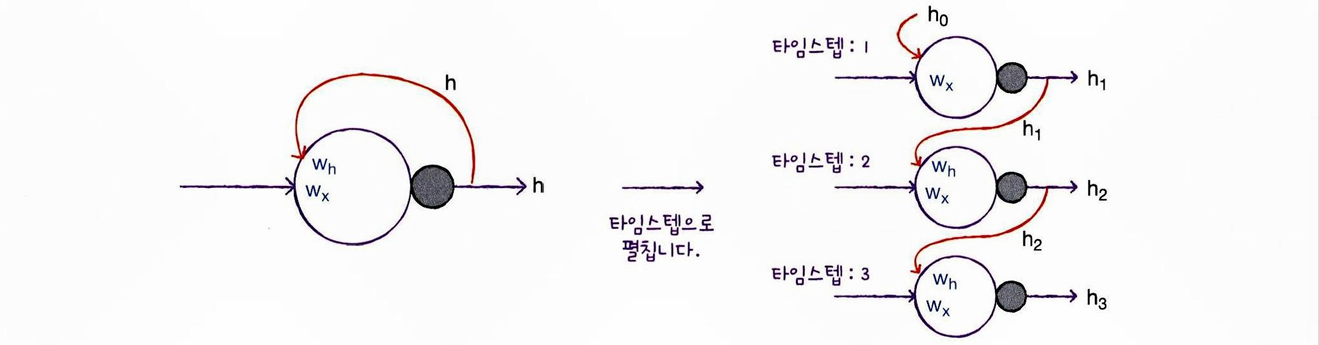

In [ ]:
# 타임스텝 1에서 셀의 출력 h1이 타임스텝 2의 셀로 주입,  이때 Wh와 곱해짐
# 타임스텝 2에서 셀의 출력 h2이 타임스텝 3의 셀로 주입,  이때에도 Wh와 곱해짐

# ⚡모든 타임스텝에서 사용되는 가중치 wh는 하나라는 점
# 가중치 wh는 타임스텝에 따라 변화되는 뉴런의 출력을 학습

🔥셀의 가중치와 입출력
###### 복잡한 모델을 배울수록 가중치 개수를 계산해 보면 잘 이해하고 있는지 알 수 있음

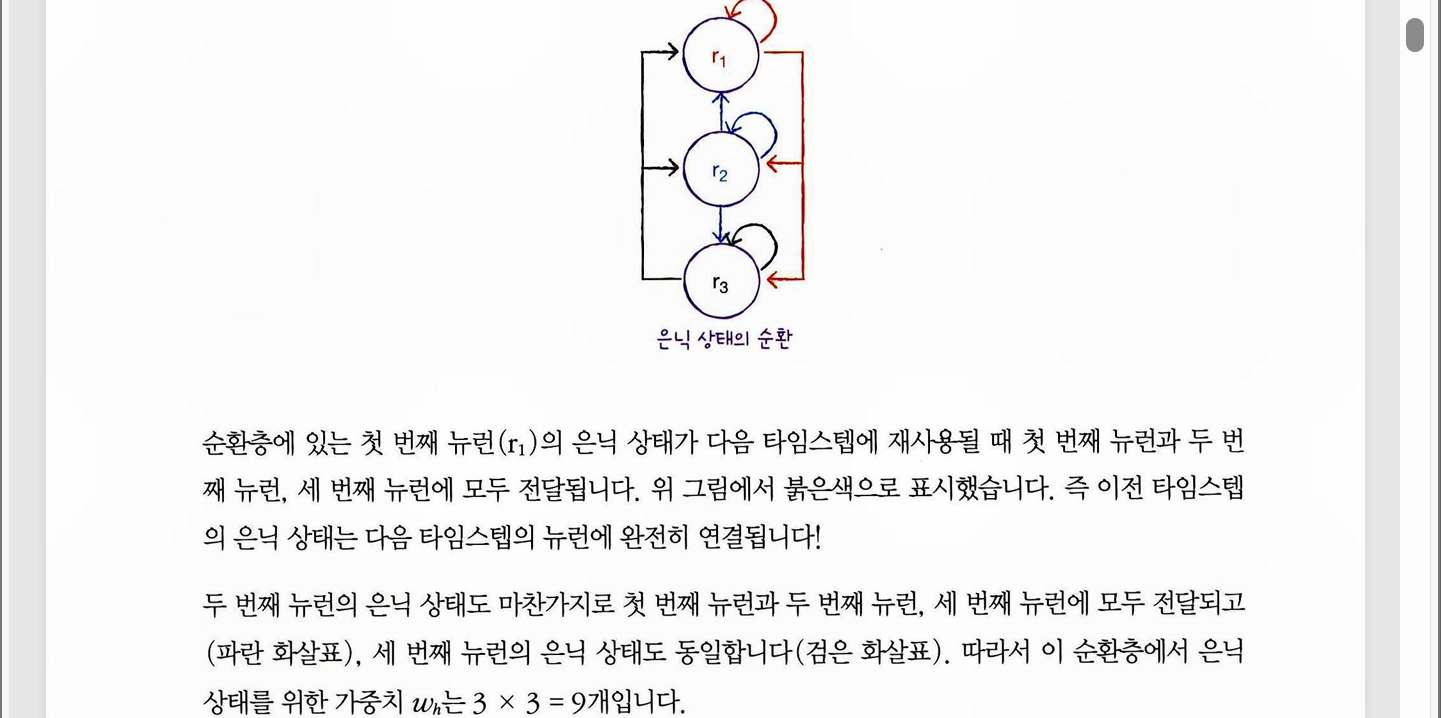

In [ ]:
# 모델 파라미터 개수를 계산해볼까요? 가중치에 절편을 더하면 됨
# 각 뉴런마다 하나의 절편
# 따라서 이 순환층은 모두 12 + 9 + 3 = 24개의 모델 파라미터

#⚡은닉 상태가 모든 뉴런에 순환되기 때문에 순환층을 셀 하나로 표시할 수밖에 없음

🔥순환층의 입력과 출력

In [ ]:
# 합성곱 층의 입력은 전형적으로 하나의 샘플이 3개의 차원을 가졌음. 너비, 높이, 채널
# 입력이 합성곱 층과 풀링 층을 통과하면 너비, 높이, 채널（혹은 깊이）의 크기가 달라지지만
# 차원의 개수는 그대로 유지

# 순환층은, 일반적으로 샘플마다 2개의 차원을 가짐
# 보통 하나의 샘플을 하나의 시퀀스sequence라고 함
# 시퀀스 안에는 여러 개의 아이템이 있다
# 시퀀스의 길이가 바로 타임스텝 길이가 됨


예를 들어 어떤 샘플에 “1am a boy”란 문장        
이 샘플은 4개의 단어로 이루어짐     
각 단어를 3개의 어떤 숫자로 표현한다고 가정     
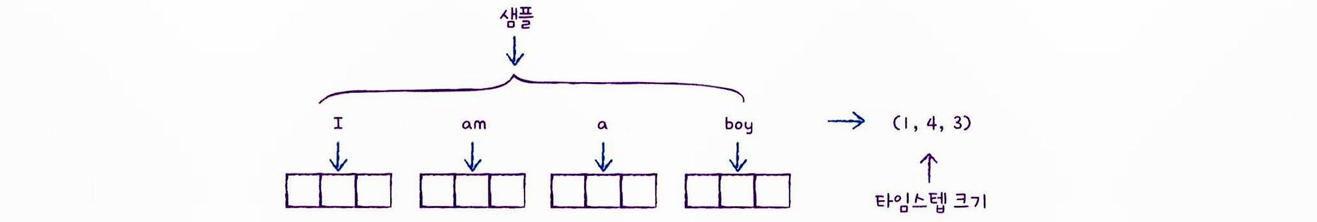
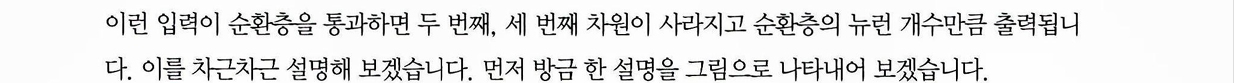
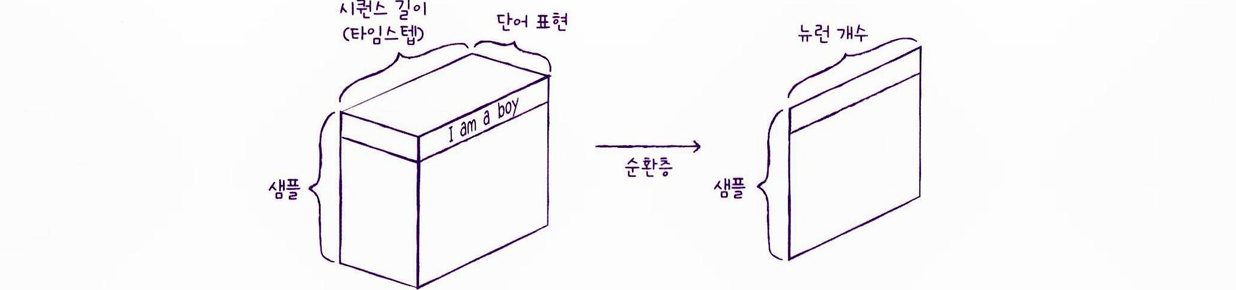

순환층을 통과하면 1차원 배열로 바뀜     
1차원 배열의 크기는 순환층의 뉴런 개수에 의해 결정 됨

순환 신경망도 완전 연결 신경망이나 합성곱 신경망처럼 여러 개의 층을 쌓을 수 있다.       
셀의 입력은 샘플마다 타임스텝과 단어 표현으로 이루어진 2차원 배열이어야 한다.       

예를 들어 2개의 순환층을 쌓은 경우      
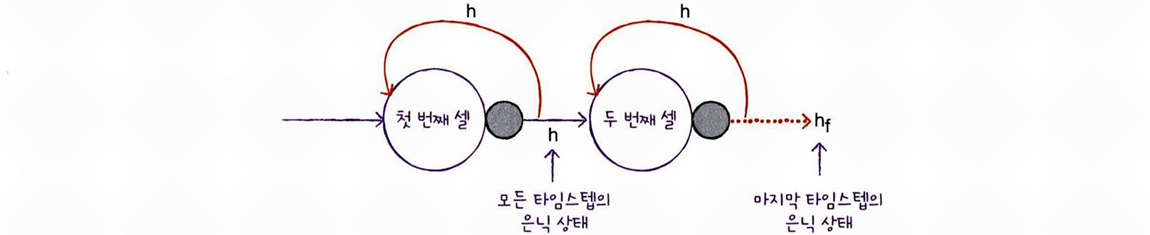
첫 번째 셀은 모든 타임스텝의 은닉 상태를 출력하고,      
두 번째 셀은 마지막 타임스텝의 은닉 상태만 출력

🔥출력층

In [ ]:
# 합성곱 신경망과 마찬가지로 순환 신경망도 마지막에는 밀집층을 두어 클래스를 분류
# 다중 분류일 경우에는 출력층에 클래스 개수만큼 뉴런을 두고 소프트맥스 활성화 함수를 사용
# 이진 분류일 경우에는 하나의 뉴런을 두고 시그모이드 활성화 함수를 사용


# ⚡합성곱 신경망과 다른 점은 마지막 셀의 출력이 1차원이기 때문에 Flatten 클래스로 펼칠 필요가 없음
# ⚡셀의 출력을 그대로 밀집층에 사용!!

In [ ]:
# 예를 들어, 다중 분류 문제에서 입력 샘플의 크기가(20, 100)일 경우 하나의 순환층을 사용하는 순환 신경망의 구조
# 샘플은 20개의 타임스텝
# 각 타임스텝은 100개의 표현 또는 특성으로 이루어짐

# 이 샘플이 순환층의 셀을 통과하면 모든 타임스텝을 처리하고 난 후의 은닉상태만 출력
# 이 은닉 상태의 크기는 셀에 있는 뉴런의 개수가 되므로 (10, )


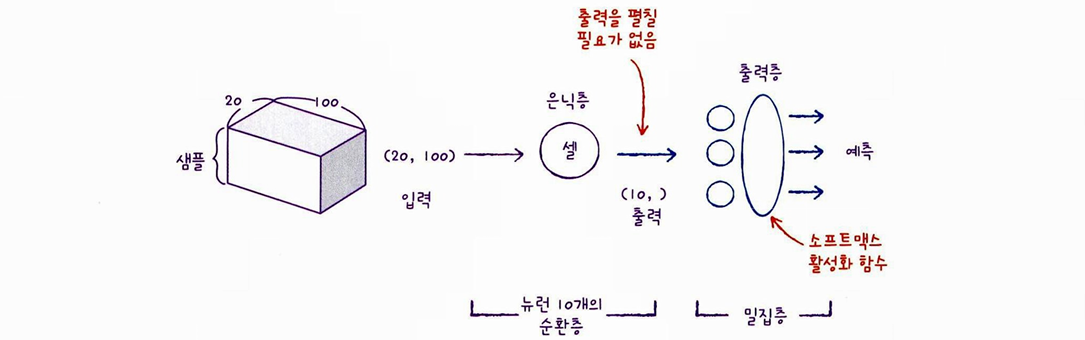

#### Chapter 09-2. 순환 신경망으로 IMDB 리뷰(데이터셋) 분류하기

이 데이터셋을 두가지 방법으로 변형하여 순환 신경망에 주입      
첫번째 : 원-핫 인코딩     
두번째 : 단어 임베딩

##### 09-2 리뷰 데이터 셋
###### 총 5만개 샘플 : 훈련 데이터와 테스트 데이터 각 2만5천개     
###### 🍋‍🟩자연어 처리(natural language processing, NLP)는 컴퓨터를 사용해 인간의 언어를 처리하는 분야    
###### 대표적인 세부 분야로는 음성 인식, 기계 번역, 감성 분석     
###### 🍋‍🟩자연어 처리 분야에서 훈련 데이터를 종종 말뭉치(corpus)라고 부름. 예를 들어 IMDB 리뷰 데이터셋이 하나의 말뭉치임

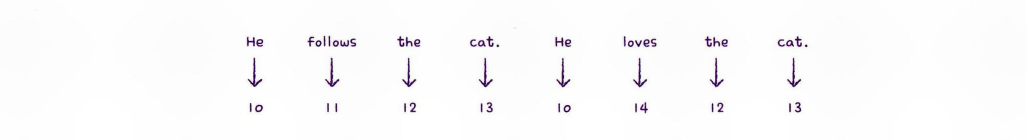      
🍋‍🟩단어에 매핑되는 정수는 단어의 의미나 크기와 관련이 없습니다.        
이 정숫값 사이에는 어떤 관계도 없습니다.        
🍋‍🟩일반적으로 영어 문장은 모두 소문자로 바꾸고 구둣점을 삭제한 다음 공백을 기준으로 분리합니다.        
🍋‍🟩이렇게 분리된 단어를 토큰이라고 부릅니다.        
🍋‍🟩하나의 샘플은 여러 개의 토큰으로 이루어져 있고 1개의 토큰이 하나의 타임스텝에 해당합니다.       

토큰에 할당하는 정수 중에 몇 개는 특정한 용도로 예약되어 있는 경우가 많습니다.      
🍋‍🟩예를 들어 0은 패딩, 1은문장의 시작, 2는 어휘 사전에 없는 토큰을 나타냅니다

In [1]:
#keras.datasets 패키지 아래 imdb 모듈을 임포트하여 이 데이터를 적재
#--실제 IMDB 리뷰 데이터셋은 영어로 된 문장이지만 편리하게도 케라스에는 이미 정수로 바꾼 데이터가 포함되어 있음

from keras.datasets import imdb
(train_input, train_target),(test_input,test_target) = imdb.load_data(num_words=200)

2026-02-09 14:00:11.881554: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-09 14:00:12.617373: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-09 14:00:16.155974: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
print(train_input.shape, test_input.shape)

# 1차원 배열로 나타남
# IMDB 리뷰 텍스트는 길이가 제각각이라 고정 크기의 2차원 배열에 담기 보다는 리뷰마다 별도의 파이썬 리스트로 담아야 메모리를 효율적 사용

(25000,) (25000,)


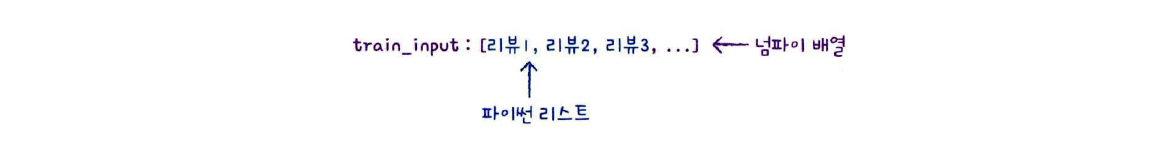
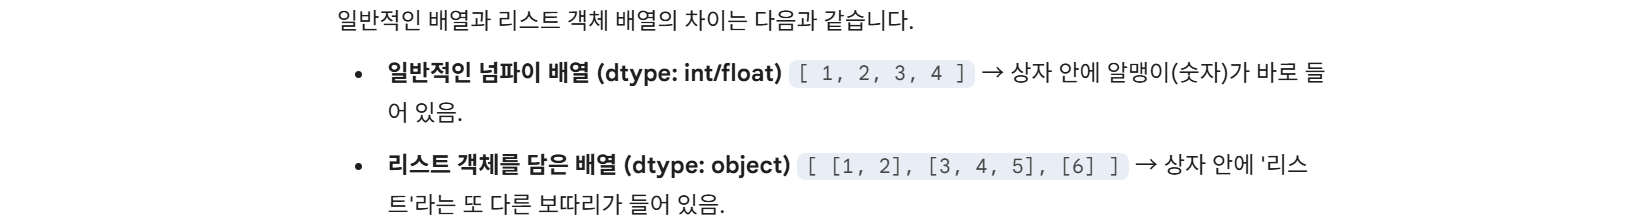

In [3]:
# 이 데이터는 개별 리뷰를 담은 파이썬 리스트 객체로 이루어진 넘파이 배열
# 넘파이 배열은 정수나 실수가 아닌 다른 파이썬 객체를 담을 수 있음
# 🍋‍🟩첫번째 리뷰 길이 출력

print(len(train_input[0]))
# 첫 번째 리뷰의 길이는 218개의 토큰

218


In [4]:
# 🍋‍🟩두번째 리뷰 길이 출력

print(len(train_input[1]))

189


In [5]:
# 🍋‍🟩첫번째 리뷰 내용 출력 (IMDB 리뷰 데이터는 이미 정수로 변환)
# 🍍앞서 num_words=200으로 지정했기 때문에 어휘 사전에는 200개의 단어만 들어가 있다.
# 🍍어휘 사전에 없는 단어는 모두 2로 표시되어 나타난다.

print(train_input[0])

[1, 14, 22, 16, 43, 2, 2, 2, 2, 65, 2, 2, 66, 2, 4, 173, 36, 2, 5, 25, 100, 43, 2, 112, 50, 2, 2, 9, 35, 2, 2, 5, 150, 4, 172, 112, 167, 2, 2, 2, 39, 4, 172, 2, 2, 17, 2, 38, 13, 2, 4, 192, 50, 16, 6, 147, 2, 19, 14, 22, 4, 2, 2, 2, 4, 22, 71, 87, 12, 16, 43, 2, 38, 76, 15, 13, 2, 4, 22, 17, 2, 17, 12, 16, 2, 18, 2, 5, 62, 2, 12, 8, 2, 8, 106, 5, 4, 2, 2, 16, 2, 66, 2, 33, 4, 130, 12, 16, 38, 2, 5, 25, 124, 51, 36, 135, 48, 25, 2, 33, 6, 22, 12, 2, 28, 77, 52, 5, 14, 2, 16, 82, 2, 8, 4, 107, 117, 2, 15, 2, 4, 2, 7, 2, 5, 2, 36, 71, 43, 2, 2, 26, 2, 2, 46, 7, 4, 2, 2, 13, 104, 88, 4, 2, 15, 2, 98, 32, 2, 56, 26, 141, 6, 194, 2, 18, 4, 2, 22, 21, 134, 2, 26, 2, 5, 144, 30, 2, 18, 51, 36, 28, 2, 92, 25, 104, 4, 2, 65, 16, 38, 2, 88, 12, 16, 2, 5, 16, 2, 113, 103, 32, 15, 16, 2, 19, 178, 32]


In [6]:
# 🍋‍🟩타깃 데이터 출력

print(train_target[:20])

# 해결할 문제는 리뷰가 긍정인지 부정인지를 판단하는 것
# 따라서 이진 분류 문제로 볼 수 있고 타깃값은 0（부정）과 1 （긍정）로 나누어 짐

[1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 1 1 0 1]


In [7]:
# 훈련 세트에서 검증 세트(20%)를 떼어 놓기

from sklearn.model_selection import train_test_split

train_input, val_input, train_target, val_target = train_test_split(
train_input, train_target, test_size=0.2, random_state=42)

In [8]:
# 훈련 세트에 대해 몇 가지 조사하기
# 먼저 각 리뷰의 길이를 계산해 넘파이 배열에 담기
# 🍋‍🟩이렇게 하는 이유 : 평균적인 리뷰의 길이와 가장 짧은 리뷰의 길이 그리고 가장 긴 리뷰의 길이를 확인하고 싶기 때문
# 🍋‍🟩이를 위해 넘파이 리스트 내포를 사용해 train_input의 원소를 순회하면서 길이를 재기

import numpy as np

lengths = np.array([len(x) for x in train_input])

In [9]:
# lengths 배열이 준비, 리뷰 길이의 평균과 중간값을 구하기
print(np.mean(lengths), np.median(lengths))

239.00925 178.0


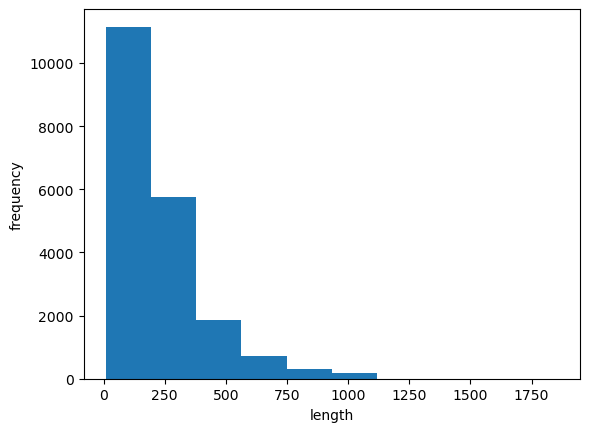

In [10]:
# lengths 배열을 히스토그램으로 표현

import matplotlib.pyplot as plt

plt.hist(lengths)
plt.xlabel('length')
plt.ylabel('frequency')
plt.show()

#⬇️그래프 해석
# 리뷰의 평균 단어 개수는 239개이고 중간값이 178
# 한쪽 치우침, 대개 리뷰 길이 300미만, 평균이 중간값보다 높은 이유는 오른쪽 끝에 아주 큰 데이터가 있기 때문
# 어떤 리뷰는 1,000개의 단어가 넘기도 함

In [11]:
# 케라스는 시퀀스 데이터의 길이를 맞추는 pad_sequences() 함수를 제공
# 이 함수를 사용해 train_input의 길이를 100으로 맞추기

from keras.preprocessing.sequence import pad_sequences

train_seq = pad_sequences(train_input, maxlen=100)
#🍍maxlen에 원하는 길이를 지정하면 이보다 긴 경우는 잘라내고 짧은 경우는 0 으로 패딩

In [ ]:
# 패딩된 train_seq의 크기 확인

print(train_seq.shape)

(20000, 100)


🍍train_input은 파이썬 리스트의 배열, 길이를 100으로 맞춘 train_seq는 이제(20000,100)크기의 2차원 배열

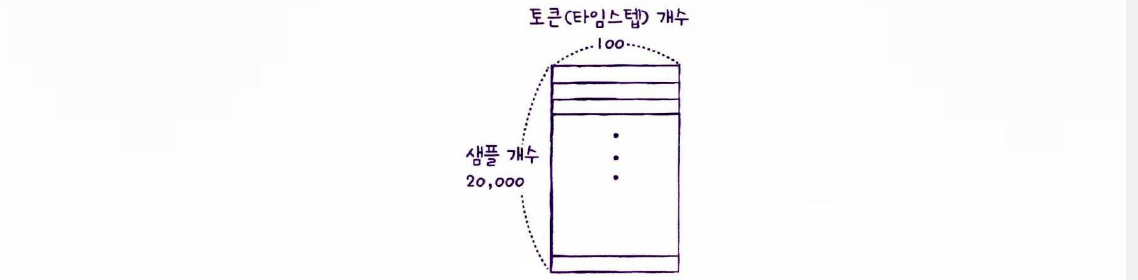

In [13]:
#train_seq에 있는 첫 번째 샘플을 출력

print(train_seq[0])
#⬇️결과 해석 : 이 샘플의 앞뒤에 패딩값 0이 없는 것으로 보아 100보다는 길었을 것

[ 10   4  20   9   2   2   2   5  45   6   2   2  33   2   8   2 142   2
   5   2  17  73  17   2   5   2  19  55   2   2  92  66 104  14  20  93
  76   2 151  33   4  58  12 188   2 151  12   2  69   2 142  73   2   6
   2   7   2   2 188   2 103  14  31  10  10   2   7   2   5   2  80  91
   2  30   2  34  14  20 151  50  26 131  49   2  84  46  50  37  80  79
   6   2  46   7  14  20  10  10   2 158]


In [14]:
#그럼 원래 샘플의 앞 부분이 잘렸을까요? 뒷부분이 잘렸을까요? train_input 원본 샘플의 끝을 확인
#train_input［0]에 있는 마지막 10개의 토큰을 출력
print(train_input[0][-10:])

#⬇️결과 해석 : 출력값과 비교하면 정확히 일치. 그렇다면 샘플의 앞부분이 잘렸다는 것을 짐작

[6, 2, 46, 7, 14, 20, 10, 10, 2, 158]


만약 시퀀스의 뒷부분을 잘라내고 싶다면 pad_sequences () 함수의 truncating 매개변수의 값을 기본값 ‘pre’가 아닌 ‘post’로 바꾸면 됩니다.

In [15]:
#train_seq에 있는 여섯 번째 샘플을 출력

print(train_seq[5])

#⬇️결과 해석 : 시퀀스의 마지막에 있는 단어가 셀의 은닉 상태에 가장 큰 영향을 미치게 되므로 마지막에 패딩을 추가하는 것은 일반적으로 선호하지 않음

[  0   0   0   0   1   2 195  19  49   2   2 190   4   2   2   2 183  10
  10  13  82  79   4   2  36  71   2   8   2  25  19  49   7   4   2   2
   2   2   2  10  10  48  25  40   2  11   2   2  40   2   2   5   4   2
   2  95  14   2  56 129   2  10  10  21   2  94   2   2   2   2  11 190
  24   2   2   7  94   2   2  10  10  87   2  34  49   2   7   2   2   2
   2   2   2   2  46  48  64  18   4   2]


In [16]:
#검증 세트의 길이도 100으로 맞추기
val_seq = pad_sequences(val_input, maxlen=100)

##### 첫번째_원-핫인코딩___순환 신경망 만들기        
###### IMDB 리뷰 분류 문제는 이진 분류이므로 마지막 출력층은 1 개의 뉴런을 가지고 시그모이드 활성화 함수를 사용해야 함‼️‼️

In [17]:
# 케라스의 Sequential 클래스로 만든 신경망 코드
# Sequential 클래스는 순환 신경망, 합성곱 신경망, 일반적인 인공 신경망 모델을 모두 만들 수 있음

import keras

model = keras.Sequential()
model.add(keras.layers.Input(shape=(100,200))) 
#Input 함수의 입력 차원을 (100, 200)으로 지정
# 첫 번째 차원이 100인 것은 앞에서 샘플의 길이를 100으로 지정했기 때문
model.add(keras.layers.SimpleRNN(8)) 
#Dense나 Conv2D 클래스 대신 SimpleRNN 클래스를 사용
model.add(keras.layers.Dense(1, activation='sigmoid'))

2026-02-09 14:01:21.626239: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [18]:
# Input 함수에서 shape 매개변수의 두 번째 차원인 200은 어디서 온 숫자일까요? 
# 이전 섹션에서 만든 train_seq와 val_seq에는 한 가지 큰 문제가 있습니다. 
# 토큰을 정수로 변환한 이 데이터를 신경망에 주입하면 큰 정수가 큰 활성화 출력을 만들기 때문입니다.
# 분명히 이 정수 사이에는 어떤 관련이 없습니다. 
# 20번 토큰을 10번 토큰보다 더 중요시해야 할 이유가 없습니다. 
# 따라서 단순한 정숫값을 신경망에 입력하기 위해서는 다른 방식을 찾아야 합니다.
# 정숫값에 있는 크기 속성을 없애고 각 정수를 고유하게 표현하는 방법은 7장에서 잠깐 보았던 원-핫 인코딩입니다.


#‼️토큰마다 200개의 숫자를 사용해 표현
# 다만 200개 중에 하나만 1이고 나머지는 모두 0으로 만들어 정수 사이에 있던 크기 속성을 없애는 원-핫 인코딩을 사용

In [ ]:
#🍋‍🟩정수 배열을 입력하면 자동으로 원-핫 인코딩된 배열을 반환
#keras.utils 패키지 아래에 있는 to_categorical() 함수
# train_seq를 원-핫 인코딩으로 변환하여 train_oh 배열을 만들기
train_oh = keras.utils.to_categorical(train_seq)

In [ ]:
#page26 ~~ 28
print(train_oh.shape)
print(train_oh[0][0][0:12])
print(np.sum(train_oh[0][0]))
#같은 방식으로 val_seq도 원-핫 인코딩
val_oh = keras.utils.to_categorical(val_seq)
#모델의 구조를 출력
model. summary()

##### 첫번째_원-핫인코딩___순환 신경망 훈련하기    

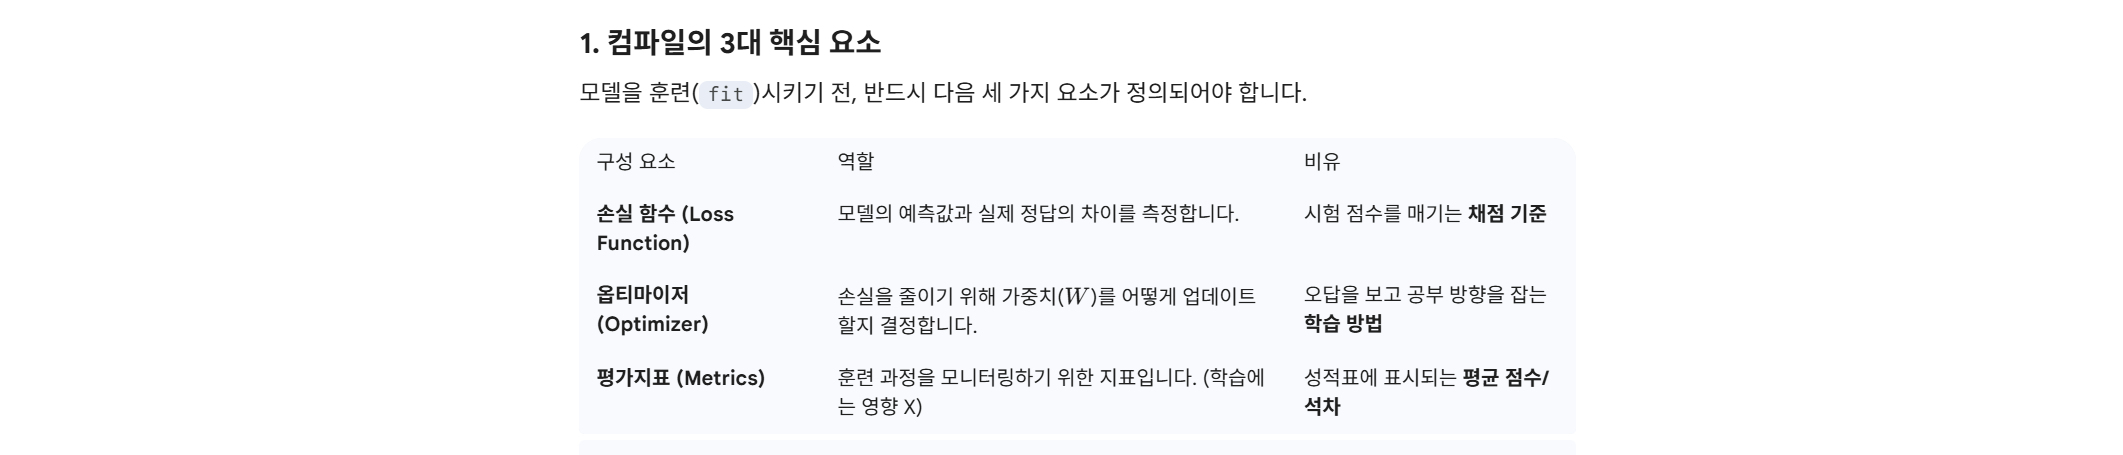

In [ ]:
#Adam 옵티마이저를 사용하고 이진 분류 문제이므로 손실 함수로 ‘binary_crossentropy’를 사용

model.compile(optimizer=' adam' , loss= 'binary_crossentropy', metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-simplernn-model.keras', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
history = model.fit(train_oh, train_target, epochs=100, batch_size=64, validation_data=(val_oh, val_target),
callbacks = [checkpoint_cb, early_stopping_cb])

In [ ]:
#훈련소실과 검증손실을 그래프
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [ ]:
#실제로 train_seq, train_oh 배열의 nbytes 속성 출력 크기 확인
print(train_seq.nbytes, train_oh.nbytes)

##### ‼️원-핫 인코딩의 단점은 입력 데이터가 엄청 커진다는 단점

##### ♥️두번째_단어 임베딩 사용       

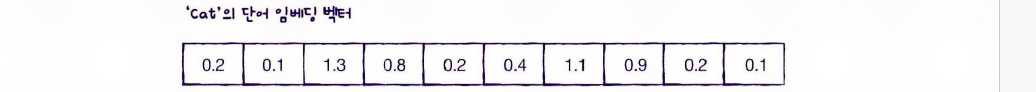

In [ ]:
# 순환 신경망에서 텍스트를 처리할 때 즐겨 사용하는 방법은 단어 임베딩 word embedding 이다     
# 단어 임베딩은 각 단어를 고정된 크기의 실수 벡터로 바꾸어 준다.      
# 단어 임베딩으로 만들어진 벡터는 원-핫 인코딩된 벡터보다 훨씬 의미 있는 값으로 채워져 있기 때문에 
#         자연어 처리에서 더 좋은 성능을 내는 경우가 많음

In [ ]:
# 단어 임베딩의 장점은 입력으로 정수 데이터를 받는다는 것입니다. 
# 즉 원-핫 인코딩으로 변경된 train_oh 배열이 아니라 train_seq를 사용할 수 있습니다. 
# 이 때문에 메모리를 훨씬 효율적으로 사용할 수 있습니다.

In [14]:
# 500개의 단어까지 선택해서 IMDB 데이터셋을 다시 만들기
from keras.datasets import imdb
from sklearn.model_selection import train_test_split
from keras.preprocessing.sequence import pad_sequences

(train_input, train_target),(test_input,test_target) = imdb.load_data(num_words=500)

train_input, val_input, train_target, val_target = train_test_split(
train_input, train_target, test_size=0.2, random_state=42)
train_seq = pad_sequences(train_input, maxlen=100)
val_seq = pad_sequences(val_input, maxlen=100)

In [15]:
#Embedding 클래스를 SimpleRNN 층 앞에 추가한 두 번째 순환 신경망 만들기
import keras
model = keras.Sequential()

model_emb = keras.Sequential()
model_emb.add(keras.layers.Input(shape=(100,)))
model_emb.add(keras.layers.Embedding(500, 16))
model_emb.add(keras.layers.SimpleRNN(8))
model_emb.add(keras.layers.Dense(1, activation='sigmoid'))

#train_seq를 그대로 사용하므로 Input 함수에 지정할 입력의 크기는 (100,)
#Embedding 클래스의 첫 번째 매개변수(500)는 어휘 사전의 크기
#imdb.load_data (num_words=500)으로 데이터를 준비했기 때문에 이 데이터셋에 있는 고유한 토큰의 개수는 총 500개
#✨이 값이 임베딩 층의 첫 번째 매개변수가 됨
#두 번째 매개변수(16)는 임베딩 벡터의 크기

In [16]:
model_emb.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 8)              │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,209 (32.07 KB)

 Trainable params: 8,209 (32.07 KB)

 Non-trainable params: 0 (0.00 B)

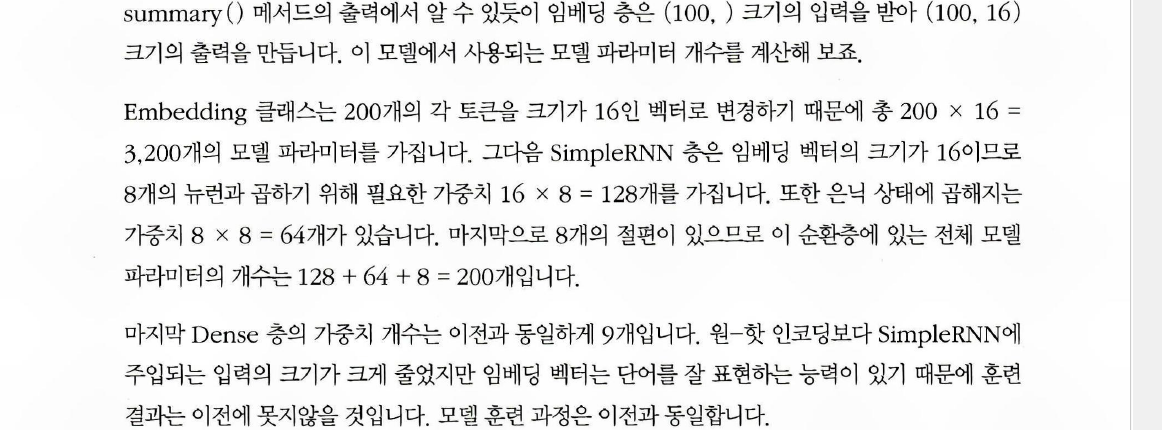

In [ ]:
model_emb.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint('best-embedding-model.keras',save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,restore_best_weights=True)
history = model_emb.fit(train_seq, train_target, epochs=100, batch_size=64,
                        validation_data=(val_seq, val_target),
                        callbacks = [checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.6710 - loss: 0.6125 - val_accuracy: 0.7540 - val_loss: 0.5269
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7653 - loss: 0.4985 - val_accuracy: 0.7644 - val_loss: 0.5010
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.7761 - loss: 0.4783 - val_accuracy: 0.7742 - val_loss: 0.4899
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.7785 - loss: 0.4721 - val_accuracy: 0.7766 - val_loss: 0.4869
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7853 - loss: 0.4602 - val_accuracy: 0.7242 - val_loss: 0.5861
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.7864 - loss: 0.4591 - val_accuracy: 0.7474 - val_loss: 0.5158
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.7905 - loss: 0.4549 - val_accuracy: 0.7694 - val_loss: 0.4920


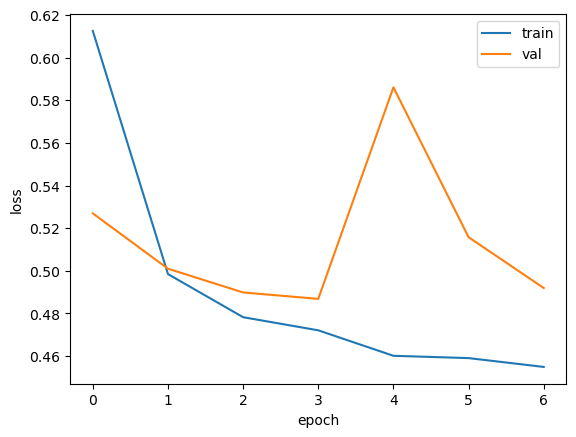

In [19]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [20]:
# 검증 손실이 더 감소되지 않아 훈련이 적절히 조기 종료된 것 같습니다. 
# 이에 비해 훈련 손실은 계속 감소합니다. 이를 더 개선할 방법이 있는지 다음 절에서 알아보겠습니다.

##### 케라스 API 로 순환 신경망 구현

In [ ]:
# """# 순환신경망으로 IMDB 리뷰 분류하기"""
# """# IMDB 리뷰 데이터 셋"""

# from keras.datasets import imdb
# (train_input, train_target),(test_input,test_target) = imdb.load_data(num_words=200)
# print(train_input.shape, test_input.shape)
# print(len(train_input[0]))
# print(len(train_input[1]))
# print(train_input[0])
# print(train_target[:20])

# from sklearn.model_selection import train_test_split

# train_input, val_input, train_target, val_target = train_test_split(
# train_input, train_target, test_size=0.2, random_state=42)

# import numpy as np

# lengths = np.array([len(x) for x in train_input])
# print(np.mean(lengths), np.median(lengths))

# import matplotlib.pyplot as plt

# plt.hist(lengths)
# plt.xlabel('length')
# plt.ylabel('frequency')
# plt.show()

# from keras.preprocessing.sequence import pad_sequences
# train_seq = pad_sequences(train_input, maxlen=100)
# print(train_seq.shape)
# print(train_seq[0])
# print(train_input[0][-10:])
# print(train_seq[5])
# val_seq = pad_sequences(val_input, maxlen=100)

# """##순환 신경망 만들기"""
# import keras

# model = keras.Sequential()
# model.add(keras.layers.Input(shape=(100,200))) 
# model.add(keras.layers.SimpleRNN(8)) 

# model.add(keras.layers.Dense(1, activation='sigmoid'))
# train_oh = keras.utils.to_categorical(train_seq)

# #page26 ~~ 28
# print(train_oh.shape)
# print(train_oh[0][0][0:12])
# print(np.sum(train_oh[0][0]))
# #같은 방식으로 val_seq도 원-핫 인코딩
# val_oh = keras.utils.to_categorical(val_seq)
# model. summary()

# """##순환 신경망 훈련하기"""

# model.compile(optimizer=' adam' , loss= 'binary_crossentropy', metrics=['accuracy'])
# checkpoint_cb = keras.callbacks.ModelCheckpoint('best-simplernn-model.keras', save_best_only=True)
# early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
# history = model.fit(train_oh, train_target, epochs=100, batch_size=64, validation_data=(val_oh, val_target),
# callbacks = [checkpoint_cb, early_stopping_cb])

# plt.plot(history.history['loss'], label='train')
# plt.plot(history.history['val_loss'], label='val')
# plt.xlabel('epoch')
# plt.ylabel('loss')
# plt.legend()
# plt.show()


# """##단어 임베딩을 사용하기"""
# train_input, val_input, train_target, val_target = train_test_split(
# train_input, train_target, test_size=0.2, random_state=42)
# train_seq = pad_sequences(train_input, maxlen=100)
# val_seq = pad_sequences(val_input, maxlen=100)

# model_emb = keras.Sequential()
# model_emb.add(keras.layers.Input(shape=(100,)))
# model_emb.add(keras.layers.Embedding(500, 16))
# model_emb.add(keras.layers.SimpleRNN(8))
# model_emb.add(keras.layers.Dense(1, activation='sigmoid'))
# model_emb.summary()

# model_emb.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# checkpoint_cb = keras.callbacks.ModelCheckpoint('best-embedding-model.keras',save_best_only=True)
# early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,restore_best_weights=True)
# history = model_emb.fit(train_seq, train_target, epochs=100, batch_size=64,
#                         validation_data=(val_seq, val_target),
#                         callbacks = [checkpoint_cb, early_stopping_cb])

# plt.plot(history.history['loss'], label='train')
# plt.plot(history.history['val_loss'], label='val')
# plt.xlabel('epoch')
# plt.ylabel('loss')
# plt.legend()
# plt.show()


##### 케라스 vs 파이토치

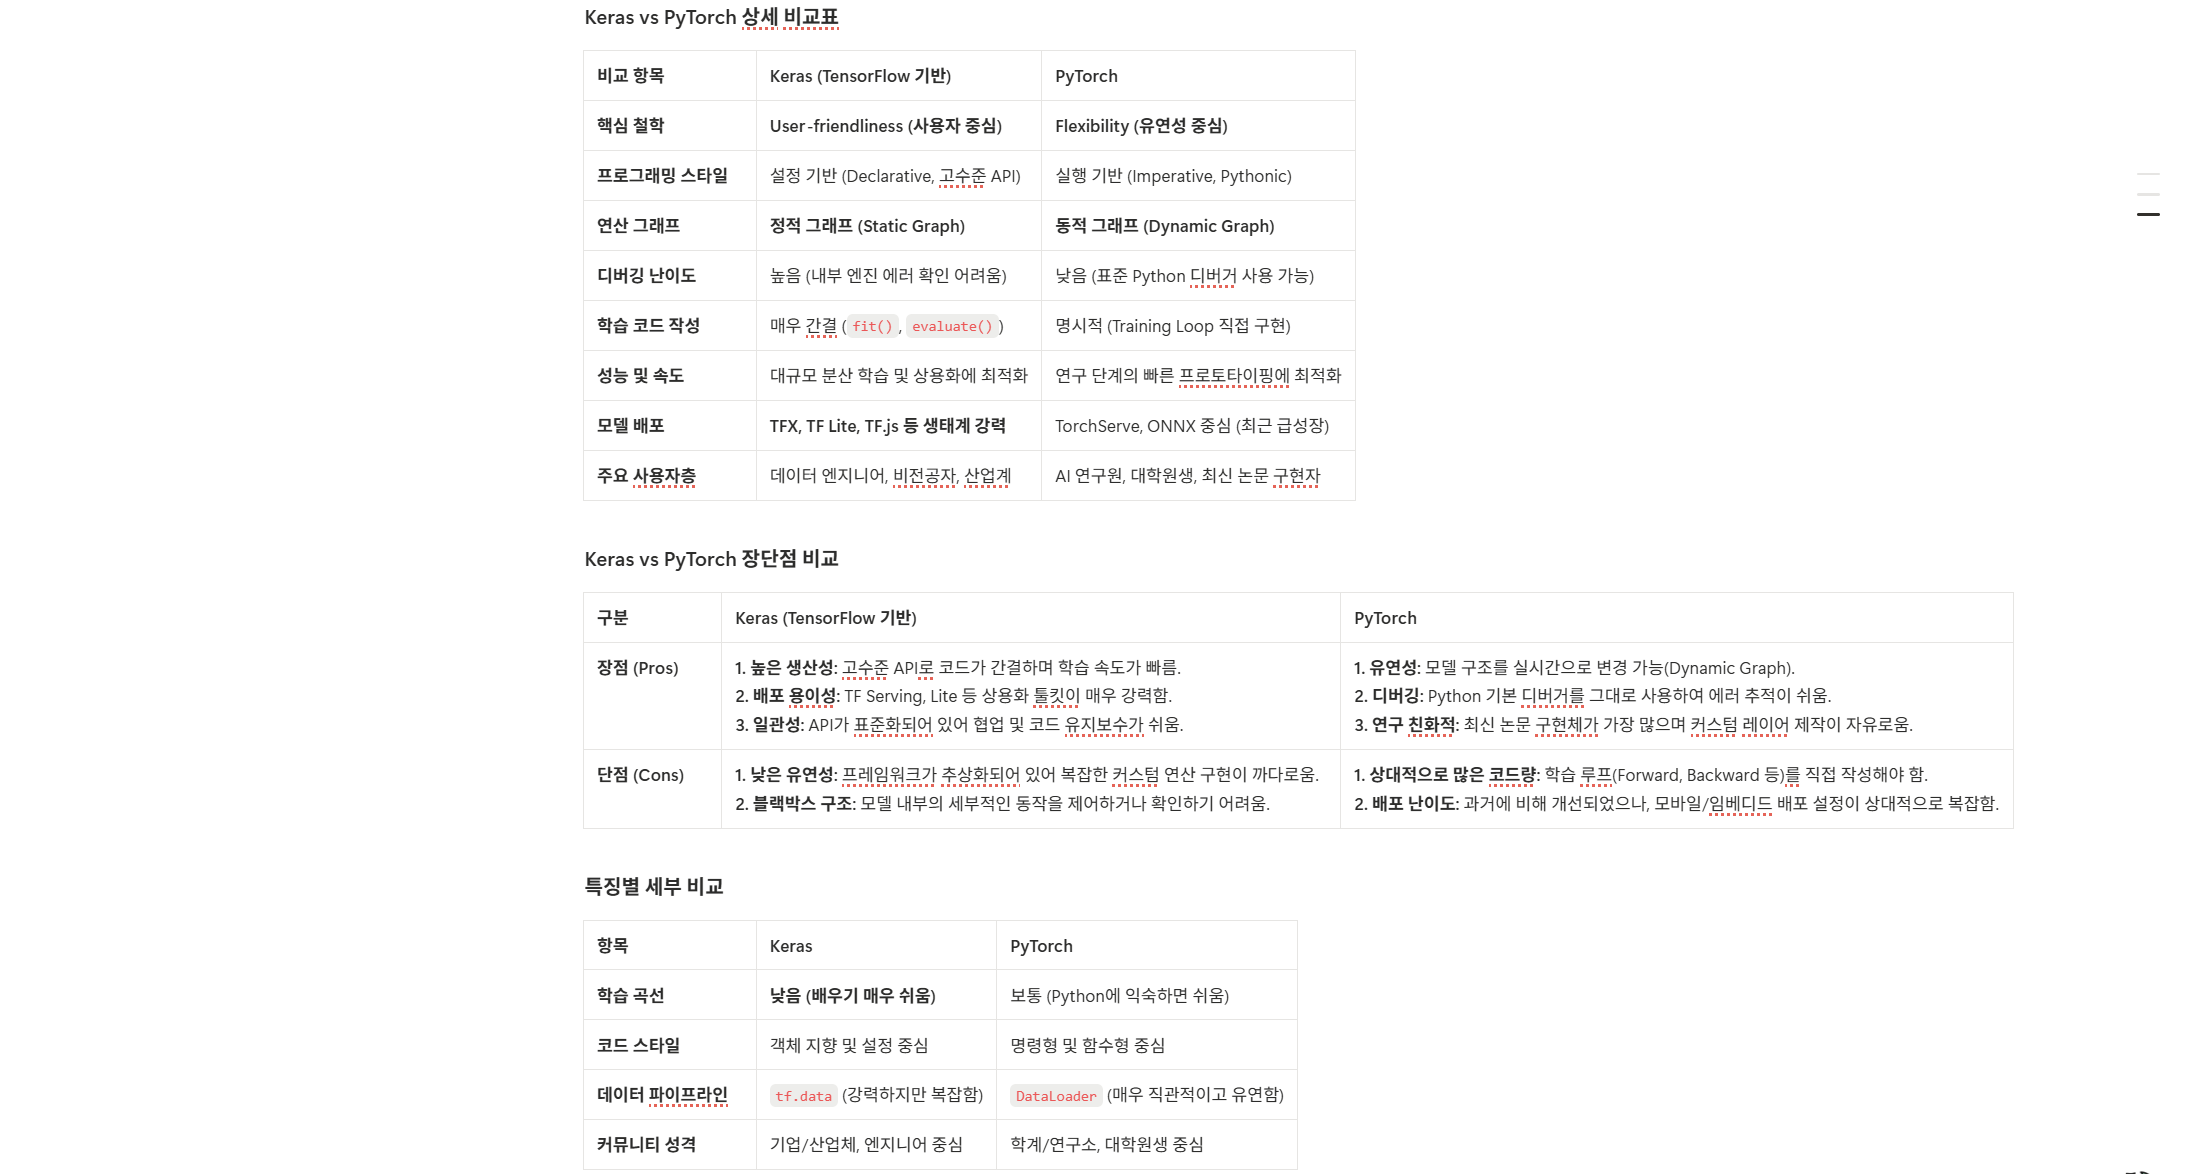
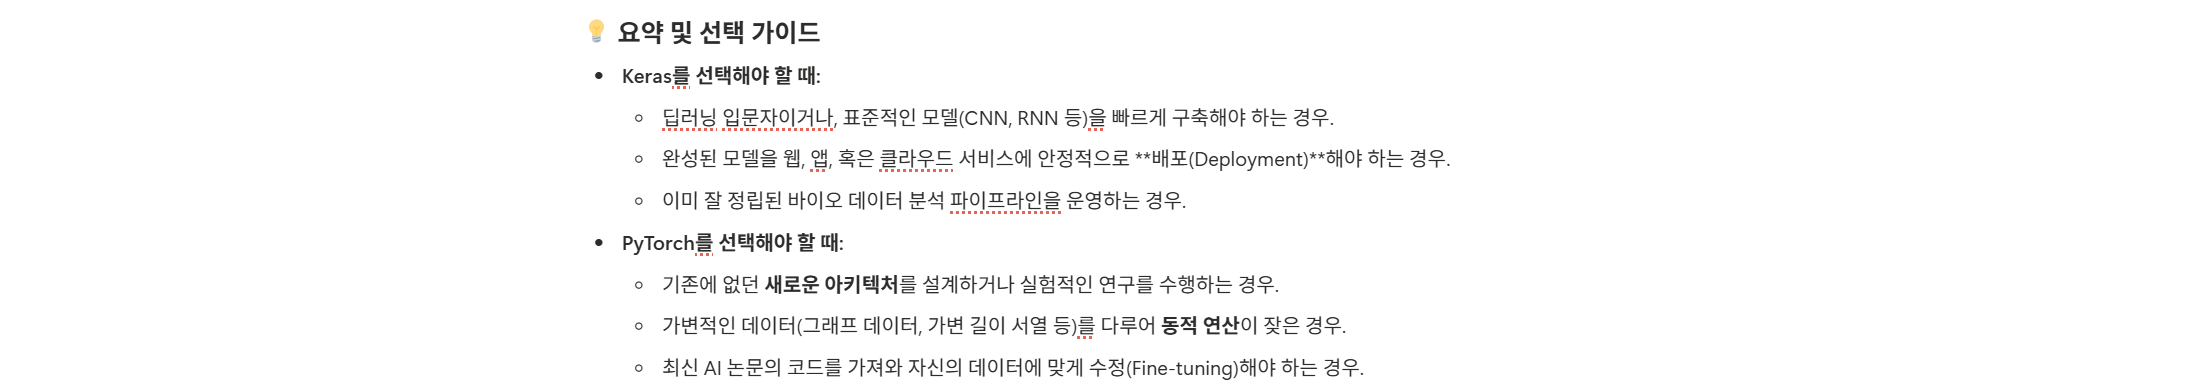

##### 파이토치로 순환 신경망 만들기

In [1]:
from keras.datasets import imdb
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) = imdb.load_data(num_words=500)
train_input, val_input, train_target, val_target = train_test_split(
train_input, train_target, test_size=0.2, random_state=42)

from keras.preprocessing.sequence import pad_sequences

train_seq = pad_sequences(train_input, maxlen=100)
val_seq = pad_sequences(val_input, maxlen=100)

print(train_seq.shape, train_target.shape)
#train_seq에는 20,000개의 샘플이 있으며, 각 샘플의 길이는 100

2026-02-09 16:12:26.821429: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-09 16:12:27.549231: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-09 16:12:30.288163: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


(20000, 100) (20000,)


In [2]:
#케라스로 준비한 이 데이터는 넘파이 배열, 파이토치의 데이터로더에 사용하려면 이를 파이토치 텐서로 변환해야 한다.
#이때 torch.tensorO 함수를 사용하면 리스트나 튜플과 같은 파이썬 데이터 타입을 파이토치 텐서로 바꿀 수 있다.

import torch

train_seq = torch.tensor(train_seq)
val_seq = torch.tensor(val_seq)

print(train_target.dtype)

int64


In [5]:
#출력 결과를 보면 train_target은 64비트 정수입니다.
#본문에서 살펴보았듯이 train_target은 긍정또는 부정을 나타내는 1과 0으로 채워져 있습니다. 
#그런데 파이토치 손실 함수는 입력으로 실숫값을 기대합니다. 
#따라서 train_target과 val_target을 실수형 텐서로 바꾸어 주겠습니다.

train_target = torch.tensor(train_target, dtype=torch.float32)
val_target = torch.tensor(val_target, dtype=torch.float32)

print(train_target.dtype)

torch.float32


In [6]:
#데이터 로더로 훈련 세트와 검증 세트를 준비

from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(train_seq, train_target)
val_dataset = TensorDataset(val_seq, val_target)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)


In [7]:
#이제 모델을 구현할 차례
#파이토치의 RNN 층은 모든 타임스텝의 출력과 최종 은닉 상태, 두가지 값을 반환합니다. 
#따라서 Sequential 클래스를 사용하여 모델을 구현하기에는 어려움이 있습니다. 
#대신 nn.Module의 서브 클래스를 만들어 모델을 구현하면 손쉽게 RNN 모델을 만들 수 있습니다.

In [8]:
import torch.nn as nn
class IMDBRnn(nn.Module): #🍋‍🟩nn.Module 클래스를 상속한 IMDBRnn 클래스를 선언
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(500, 16)
        self.rnn = nn.RNN(16, 8, batch_first=True)
        self.dense = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        x = self.embedding(x)
        _, hidden = self.rnn(x)
        outputs = self.dense(hidden[-1])
        return self.sigmoid(outputs)
    
#이 클래스에 꼭 필요한 메서드는 생성자인 _Jnit__()와 정방향 계산을 담당할 forward()
#위 코드에서는 임베딩 층, 순환층, 밀집층, 시그모이드 활성화 함수를 위한 층을 선언

# self.embedding = nn.Embedding(500, 16)
# 파이토치에서 임베딩 층은 nn.Embedding 클래스에 구현
# 케라스와 마찬가지로 첫 번째 매개변수에는 어휘 사전의 크기, 두 번째 매개변수에는 임베딩 벡터의 크기를 지정. 
# 이 객체에 （배치 크기, 시퀀스 길이） 크기의 입력을 전달하면 （배치 크기, 시퀀스 길이, 임베딩 크기)의 출력을 만든다.

# self.rnn = nn.RNN(16, 8, batch_first=True)
# 파이토치의 기본 순환층인 nn.RNN 클래스의 객체
# 이 클래스의 첫 번째 매개변수에는 입력 크기 （임베딩 벡터의 크기, 두 번째 매개변수에는 출력 크기 （뉴런 개수）를 지정한다.
# 파이토치의 순환층은 기본적으로 입력 차원의 순서가 （시퀀스 길이, 배치 크기, 임베딩 크기）라고 가정한다.
# 하지만 이 예에서 임베딩 층을 통과한 출력은 배치 크기가 맨 앞에 놓여 （배치 크기, 시퀀스 길이, 임베딩 크기）의 크기를 가진다.
# 따라서 배치 차원이 맨 앞이라는 것을 알리기 위해 batch_first 매개변수를True로 지정한다.
# 이 매개변수의 기본값은 False.

# self.dense = nn.Linear(8, 1)
# 입력의 크기가 8이고 출력 크기가 1 인 nn.Linear 층을 만든다.
# 이진 분류이므로 마지막에 시그모이드 활성화 함수를 놓기 위해 nn.Sigmoid 층을 만든다
# 이전에는 파이토치로 다중 분류 모델을 만들 때 마지막에 소프트맥스 함수를 놓지 않았음. 
# nn.CrossEntropyLoss 손실이 소프트맥스 함수를 포함하고 있기 때문입니다. 
# 이진 분류의 경우도 시그모이드 함수가 포함된 손실 함수를 사용할 수 있지만 여기에서는 다른 예를 보이기 위해 일부러 시그모이드 함수를 마지막에 추가

# def forward(self, x):
# forward（） 메서드에는 __init_（） 메서드에서 정의한 층을 사용해 입력에서 출력까지 층 객체를 호출
# 이 과정은 08-3절의 파이토치 예제에서 합성곱 층의 특성 맵을 시각화할 때 사용한 방식과 같음

# 한가지 주의할 점은 nn.RNN 클래스는 마지막 층에서 나온 각 타임스텝의 은닉 상태와 모든 층의 최종 은닉 상태 두 개를 반환한다는 것. 
# 케라스와 달리 파이토치는 여러 개의 순환층을 쌓기 위해 nn.RNN 클래스의 객체를 여러 개 만들 필요가 없이 num_layers 매개변수에서
# 층 개수를 지정하면 된다. 기본값은 1 이므로 이 예에서는 하나의 층을 사용한다.


# 각 타임스텝의 은닉 상태는 batch_first=True로 지정된 경우 크기가 （배치 크기, 시퀀스 길이, 뉴런개수）이고 
# batch_first=False이면 （시퀀스 길이, 배치 크기, 뉴런 개수）
# 두 번째 반환 값인 최종 은닉 상태의 크기는 （층 개수, 배치 크기, 뉴런 개수）이다.
# 이 예제는 각 샘플의 길이가 100이고 1 개의 순환층과 64개의 배치를 사용하므로 
# 첫 번째 출력의 크기는 （64, 100, 8）이고, 두 번째 출력의 크기는（1,64, 8）

In [9]:
#IMDBRnn 클래스로 모델 객체를 만들고 GPU로 전달

model = IMDBRnn()
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

IMDBRnn(
  (embedding): Embedding(500, 16)
  (rnn): RNN(16, 8, batch_first=True)
  (dense): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [10]:
#손실 함수와 옵티마이저를 정의
#이진 분류의 경우 모델의 마지막 층으로 시그모이드 함수를 추가했기 때문에 nn.BCELoss를 사용
#옵티마이저는 이전과 동일하게 Adam을 사용하되 학습률을 기본값보다 조금 낮춰 2e-4로 설정

import torch.optim as optim
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=2e-4)

#이 모델은 (64, 100)크기의 배치 입력을 받아 마지막 시그모이드 함수를 통과한 (64, 1) 크기의 값을 출력
#그러나 앞서 준비한 타깃값은 1차원 배열
#따라서 데이터로더 가 반환한 타깃의 크기는 (64, )
#손실 함수에서 이 두 값을 사용하려면 차원이 같아야 함

In [19]:
#따라서 파이토치 텐서의 squeeze () 메서드를 사용해 크기가 1인 차원을 삭제한 후 criterion 객체에 전달

# train_hist = []
# val_hist = []
# patience = 2
# best_loss = -1
# early_stopping_counter = 0
# epochs = 100

# for epoch in range(epochs):
#     model.train()
#     train_loss = 0
    
#     for inputs, targets in train_loader:
#         inputs, targets = inputs.to(device), targets.to(device)
#         optimizer.zero_grad()
#         outputs = model(inputs)
#         loss = criterion(outputs.squeeze(), targets)
#         loss.backward()
#         optimizer.step()
#         train_loss += loss.item()
    
#     model.eval()
#     val_loss = 0
    
#     with torch.no_grad():
#         for inputs, targets in val_loader:
#             inputs, targets = inputs.to(device), targets.to(device)
#             outputs = model(inputs)
#             loss = criterion(outputs.squeeze(), targets)
#             val_loss += loss.item()
    
#     train_loss = train_loss / len(train_loader)
#     val_loss = val_loss / len(val_loader)
#     train_hist.append(train_loss)
#     val_hist.append(val_hist)
    
#     print(f"에포크: {epoch+1}, 훈련 손실: {train_loss:.4f}, 검증 손실: {val_loss:.4f}")
    
#     if best_loss == -1 or val_loss < best_loss:
#         best_loss = val_loss
#         early_stopping_counter = 0
#         torch.save(model.state_dict(), 'best_rnn_model.pt')
#     else:
#         early_stopping_counter += 1
#         if early_stopping_counter >= patience:
#             print(f"{epoch+1}번째 에포크에서 조기 종료되었습니다.")
#             break

# 기존 데이터 삭제
train_hist = []
val_hist = []

patience = 2
best_loss = float('inf')  # -1보다 inf가 더 명확
early_stopping_counter = 0
epochs = 100

for epoch in range(epochs):
    model.train()
    train_loss = 0
    
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs.squeeze(), targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs.squeeze(), targets)
            val_loss += loss.item()
    
    train_loss = train_loss / len(train_loader)
    val_loss = val_loss / len(val_loader)
    train_hist.append(train_loss)
    val_hist.append(val_loss)  # ✅ 수정: val_hist → val_loss
    
    print(f"에포크: {epoch+1}, 훈련 손실: {train_loss:.4f}, 검증 손실: {val_loss:.4f}")
    
    if val_loss < best_loss:  # best_loss == -1 체크 불필요
        best_loss = val_loss
        early_stopping_counter = 0
        torch.save(model.state_dict(), 'best_rnn_model.pt')
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= patience:
            print(f"{epoch+1}번째 에포크에서 조기 종료되었습니다.")
            break

에포크: 1, 훈련 손실: 0.5429, 검증 손실: 0.5926
에포크: 2, 훈련 손실: 0.5435, 검증 손실: 0.5882
에포크: 3, 훈련 손실: 0.5422, 검증 손실: 0.5879
에포크: 4, 훈련 손실: 0.5397, 검증 손실: 0.5864
에포크: 5, 훈련 손실: 0.5365, 검증 손실: 0.5860
에포크: 6, 훈련 손실: 0.5346, 검증 손실: 0.5849
에포크: 7, 훈련 손실: 0.5381, 검증 손실: 0.5841
에포크: 8, 훈련 손실: 0.5339, 검증 손실: 0.5823
에포크: 9, 훈련 손실: 0.5293, 검증 손실: 0.5806
에포크: 10, 훈련 손실: 0.5294, 검증 손실: 0.5785
에포크: 11, 훈련 손실: 0.5264, 검증 손실: 0.5827
에포크: 12, 훈련 손실: 0.5251, 검증 손실: 0.5778
에포크: 13, 훈련 손실: 0.5241, 검증 손실: 0.5787
에포크: 14, 훈련 손실: 0.5239, 검증 손실: 0.5770
에포크: 15, 훈련 손실: 0.5237, 검증 손실: 0.5773
에포크: 16, 훈련 손실: 0.5193, 검증 손실: 0.5747
에포크: 17, 훈련 손실: 0.5165, 검증 손실: 0.5732
에포크: 18, 훈련 손실: 0.5170, 검증 손실: 0.5723
에포크: 19, 훈련 손실: 0.5139, 검증 손실: 0.5696
에포크: 20, 훈련 손실: 0.5153, 검증 손실: 0.5705
에포크: 21, 훈련 손실: 0.5126, 검증 손실: 0.5697
21번째 에포크에서 조기 종료되었습니다.


In [20]:
# val_hist의 내용 확인
print(f"val_hist 타입: {type(val_hist)}")
print(f"val_hist 길이: {len(val_hist)}")
print(f"첫 3개 요소: {val_hist[:3]}")
print(f"각 요소 타입: {type(val_hist[0])}")

# 텐서인지 확인
import torch
if isinstance(val_hist[0], torch.Tensor):
    print("텐서가 들어있습니다!")

val_hist 타입: <class 'list'>
val_hist 길이: 21
첫 3개 요소: [0.5926272099531149, 0.5881991299647319, 0.5878662357601938]
각 요소 타입: <class 'float'>


In [ ]:
# import matplotlib.pyplot as plt

# plt.plot(train_hist, label='train')
# plt.plot(val_hist, label='val')
# plt.xlabel('epoch')
# plt.ylabel('loss')
# plt.legend()
# plt.show()

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(train_hist, label='Train Loss', marker='o', markersize=3)
plt.plot(val_hist, label='Validation Loss', marker='s', markersize=3)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('loss_plot.png', dpi=150, bbox_inches='tight')
plt.close()
print("그래프 저장 완료: loss_plot.png")

그래프 저장 완료: loss_plot.png


In [24]:
model.load_state_dict(torch.load('best_rnn_model.pt', weights_only=True))

model.eval()
corrects = 0
with torch.no_grad():
    for inputs, targets in val_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        predicts = outputs > 0.5
        corrects += (predicts.squeeze() == targets).sum().item()

accuracy = corrects / len(val_dataset)
print(f"검증 정확도: {accuracy: .4f}")

검증 정확도:  0.7120


#### Chapter 09-3. LSTM과 GRU 셀

#### LSTM(Long Short-Term Memory) 구조      

LSTM(Long Short-Term Memory)은 시계열 데이터를 처리하는 딥러닝 아키텍처     
단기 기억을 오래 기억하기 위해 고안됨       

LSTM에는 입력과 가중치를 곱하고 절편을 더해 활성화 함수를 통과시키는 구조를 여러 개 가지고 있다.      
이런 계산 결과는 다음 타임스텝에 재사용된다.

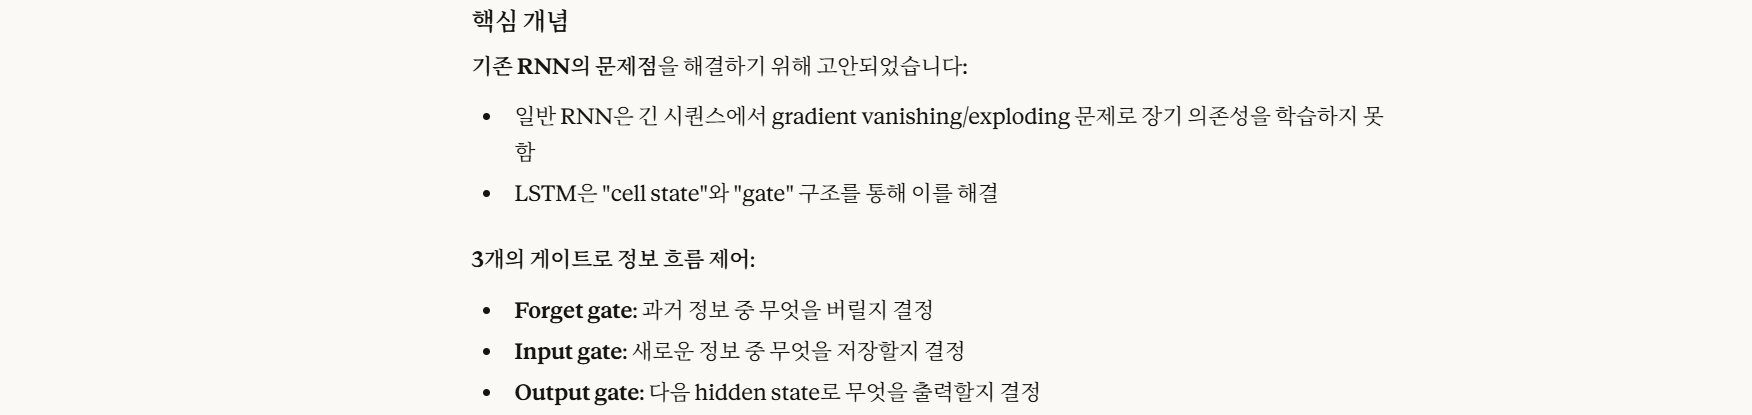
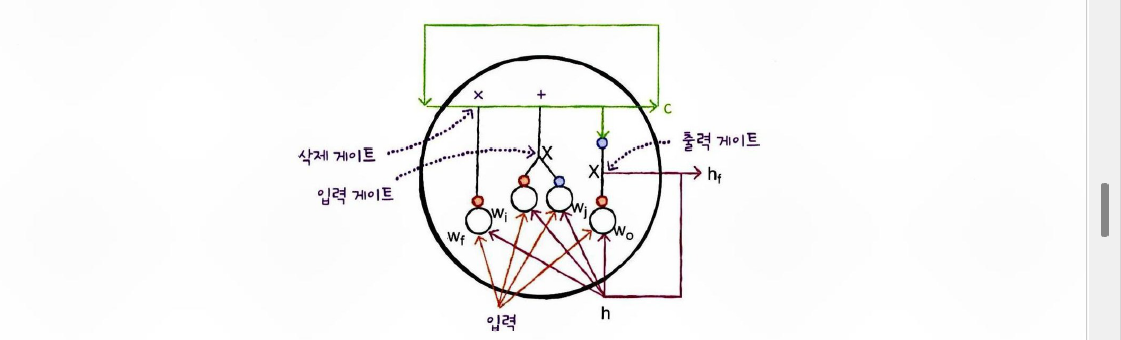

In [25]:
# LSTM 신경망 훈련하기
#IMDB 리뷰 데이터를 로드하고 훈련 세트와 검증 세트로 나누기, 500개의 단어 사용


from keras.datasets import imdb
from sklearn.model_selection import train_test_split
(train_input, train_target), (test_input, test_target) = imdb.load_data(
num_words=500)
train_input, val_input, train_target, val_target = train_test_split(
train_input, train_target, test_size=0.2, random_state=42)

In [26]:
#케라스의 pad_sequences() 함수로 각 샘플의 길이를 100에 맞추고 부족할 때는 패딩을 추가
from keras.preprocessing.sequence import pad_sequences

train_seq = pad_sequences(train_input, maxlen=100)
val_seq = pad_sequences(val_input, maxlen=100)

In [27]:
#🍋‍🟩LSTM 셀을 사용한 순환층 만들기

import keras

model_lstm = keras.Sequential()
model_lstm.add(keras.layers.Input(shape=(100,)))
model_lstm.add(keras.layers.Embedding(500, 16))
model_lstm.add(keras.layers.LSTM(8))
model_lstm.add(keras.layers.Dense(1, activation='sigmoid'))

2026-02-09 16:46:46.869471: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [28]:
#🍋‍🟩2절에서 임베딩을 사용했던 순환 신경망 모델과 완전히 동일
# 여기에서는 SimpleRNN 대신 에 LSTM을 사용

model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,809 (34.41 KB)

 Trainable params: 8,809 (34.41 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
#모델 컴파일 후 훈련 (배치 크기 64개, 에포크 횟수 100)

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint('best-lstm-model.keras', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
history = model_lstm.fit(train_seq ,train_target, epochs=100, batch_size=64,
                         validation_data=(val_seq, val_target),
                         callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 92ms/step - accuracy: 0.6784 - loss: 0.5923 - val_accuracy: 0.7642 - val_loss: 0.5016
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 79ms/step - accuracy: 0.7832 - loss: 0.4664 - val_accuracy: 0.7628 - val_loss: 0.4938
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 50s 96ms/step - accuracy: 0.7954 - loss: 0.4411 - val_accuracy: 0.7944 - val_loss: 0.4468
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step - accuracy: 0.8051 - loss: 0.4241 - val_accuracy: 0.7988 - val_loss: 0.4307
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.8052 - loss: 0.4193 - val_accuracy: 0.8014 - val_loss: 0.4325
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 81ms/step - accuracy: 0.8108 - loss: 0.4114 - val_accuracy: 0.7958 - val_loss: 0.4317
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 72ms/step - accuracy: 0.8122 - loss: 0.4046 - val_accuracy: 0.8038 - val_loss: 0.4260
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 86ms/step - accuracy: 0.8167 - loss: 0

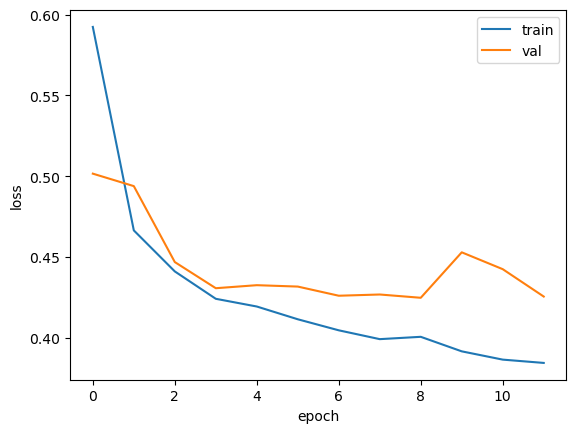

In [36]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.clf()  # 현재 figure 지우기
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()

In [38]:
#🍋‍🟩순환층에 드롭아웃 적용하기

#완전 연결 신경망과 합성곱 신경망에서는 Dropout 클래스를 사용해 드롭아웃을 적용했습니다. 
#이를 통해 모델이 훈련 세트에 너무 과대적합되는 것을 막았음
#LSTM 클래스에 dropout 매개변수를 0.2으로 지정하여 20%의 입력을 드롭아웃


model_dropout = keras.Sequential()
model_dropout.add(keras.layers.Input(shape=(100,)))
model_dropout.add(keras.layers.Embedding(500, 16))
model_dropout.add(keras.layers.LSTM(8, dropout=0.2))
model_dropout.add(keras.layers.Dense(1, activation='sigmoid'))

In [39]:
#모델을 동일한 조건으로 훈련
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint('best-lstm-model.keras', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
history = model_lstm.fit(train_seq ,train_target, epochs=100, batch_size=64,
                         validation_data=(val_seq, val_target),
                         callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 84ms/step - accuracy: 0.8174 - loss: 0.3948 - val_accuracy: 0.8040 - val_loss: 0.4220
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 83ms/step - accuracy: 0.8198 - loss: 0.3925 - val_accuracy: 0.7984 - val_loss: 0.4347
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.8195 - loss: 0.3891 - val_accuracy: 0.8040 - val_loss: 0.4289
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.8238 - loss: 0.3836 - val_accuracy: 0.8018 - val_loss: 0.4264


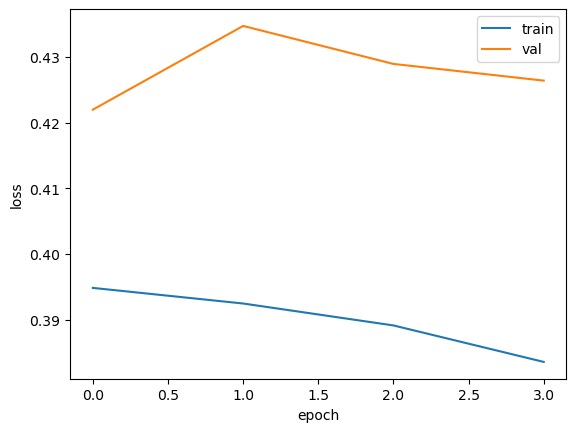

In [ ]:
#드롭아웃을 추가했더 니 모델의 성능이 약간 줄어듦?

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()


In [46]:
#🍋‍🟩 2개의 층을 연결하기
#순환층을 연결할 때는 한 가지 주의할 점이 있음
#오직 마지막 순환층만 마지막 타임스텝의 은닉 상태를 출력해야 한다.
#케라스의 순환층에서 모든 타임스텝의 은닉 상태를 출력하려면 
#마지막을 제외한 다른 모든 순환층에서 return_seqences 매개변수를 True로 지정

model_2lstm = keras.Sequential()
model_2lstm.add(keras.layers.Input(shape=(100,)))
model_2lstm.add(keras.layers.Embedding(500, 16))
model_2lstm.add(keras.layers.LSTM(8, dropout=0.2, return_sequences=True))
model_2lstm.add(keras.layers.LSTM(8, dropout=0.2))
model_2lstm.add(keras.layers.Dense(1, activation='sigmoid'))
model_2lstm.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 100, 8)         │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 8)              │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,353 (36.54 KB)

 Trainable params: 9,353 (36.54 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
model_2lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint('best-2lstm-model.keras', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
history = model_2lstm.fit(train_seq ,train_target, epochs=100, batch_size=64,
                         validation_data=(val_seq, val_target),
                         callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 129ms/step - accuracy: 0.6802 - loss: 0.5912 - val_accuracy: 0.7764 - val_loss: 0.4763
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 104ms/step - accuracy: 0.7821 - loss: 0.4685 - val_accuracy: 0.7932 - val_loss: 0.4543
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 122ms/step - accuracy: 0.7976 - loss: 0.4410 - val_accuracy: 0.7988 - val_loss: 0.4324
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 74ms/step - accuracy: 0.8014 - loss: 0.4328 - val_accuracy: 0.8068 - val_loss: 0.4226
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.8092 - loss: 0.4219 - val_accuracy: 0.8012 - val_loss: 0.4355
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 120ms/step - accuracy: 0.8111 - loss: 0.4150 - val_accuracy: 0.8102 - val_loss: 0.4203
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 132ms/step - accuracy: 0.8153 - loss: 0.4069 - val_accuracy: 0.7998 - val_loss: 0.4291
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 99ms/step - accuracy: 0.8242 - lo

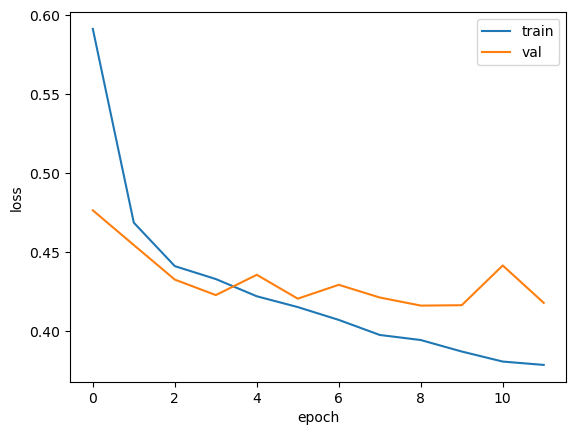

In [48]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

##### GRU(Gated Recurrent Unit) 구조        
LSTM을 간소화한 버전으로, LSTM처럼 셀 상태를 계산하지 않고 은닉 상태 하나만 포함


In [49]:
#🍋‍🟩GRU 신경망 훈련

model_gru = keras.Sequential()
model_gru.add(keras.layers.Input(shape=(100,)))
model_gru.add(keras.layers.Embedding(500, 16))
model_gru.add(keras.layers.GRU(8, dropout=0.2))
model_gru.add(keras.layers.Dense(1, activation='sigmoid'))

model_gru.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 8)              │           624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,633 (33.72 KB)

 Trainable params: 8,633 (33.72 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
model_gru.compile(optimizer='adam', loss='binary_crossentropy',metrics=['accuracy'])
                  
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-gru-model.keras', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
history = model_gru.fit(train_seq, train_target, epochs=100, batch_size=64,
                        validation_data=(val_seq, val_target),
                        callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 89ms/step - accuracy: 0.6244 - loss: 0.6370 - val_accuracy: 0.7558 - val_loss: 0.5137
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 86ms/step - accuracy: 0.7670 - loss: 0.4960 - val_accuracy: 0.7804 - val_loss: 0.4708
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 94ms/step - accuracy: 0.7878 - loss: 0.4605 - val_accuracy: 0.7902 - val_loss: 0.4531
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.7980 - loss: 0.4421 - val_accuracy: 0.7974 - val_loss: 0.4412
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - accuracy: 0.8045 - loss: 0.4283 - val_accuracy: 0.8010 - val_loss: 0.4341
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 69ms/step - accuracy: 0.8111 - loss: 0.4196 - val_accuracy: 0.7960 - val_loss: 0.4389
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 88ms/step - accuracy: 0.8123 - loss: 0.4132 - val_accuracy: 0.8020 - val_loss: 0.4297
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 123ms/step - accuracy: 0.8151 - loss: 

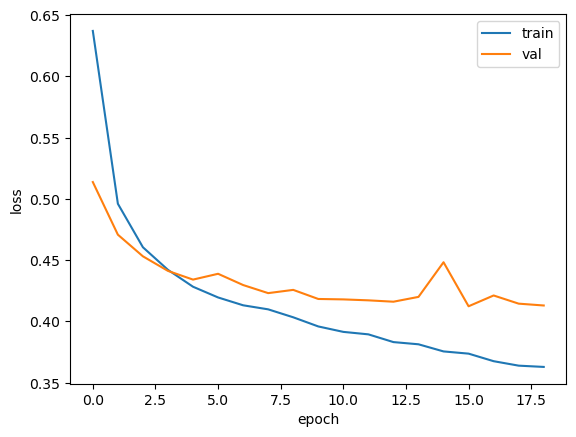

In [51]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [52]:
#🍋‍🟩훈련한 GRU 모델을 다시 로드하여 테스트 세트에 대한 성능을 확인
#테스트 세트를 훈련 세트와 동일한 방식으로 변환
#그다음 load_model() 함수를 사용해 best-gru-model.keras 파일을 읽고 evaluate() 메서드로 테스트 세트에서 성능을 계산

test_seq = pad_sequences(test_input, maxlen=100)
best_model = keras.models.load_model('best-gru-model.keras')
best_model.evaluate(test_seq, test_target)

782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.8166 - loss: 0.4012


[0.4011646807193756, 0.8165599703788757]

#### LSTM과 GRU 셀로 훈련

In [ ]:
# """# LSTM과 GRU셀"""
# """## LSTM 신경망 훈련하기"""

# # IMDB 데이터셋 로드 및 전처리
# from keras.datasets import imdb
# from sklearn.model_selection import train_test_split
# from keras.preprocessing.sequence import pad_sequences
# import keras
# import matplotlib.pyplot as plt

# (train_input, train_target), (test_input, test_target) = imdb.load_data(num_words=500)
# train_input, val_input, train_target, val_target = train_test_split(
#     train_input, train_target, test_size=0.2, random_state=42)

# train_seq = pad_sequences(train_input, maxlen=100)
# val_seq = pad_sequences(val_input, maxlen=100)


# ## 기본 LSTM 모델
# model_lstm = keras.Sequential()
# model_lstm.add(keras.layers.Input(shape=(100,)))
# model_lstm.add(keras.layers.Embedding(500, 16))
# model_lstm.add(keras.layers.LSTM(8))
# model_lstm.add(keras.layers.Dense(1, activation='sigmoid'))
# model_lstm.summary()

# model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# checkpoint_cb = keras.callbacks.ModelCheckpoint('best-lstm-model.keras', save_best_only=True)
# early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

# history = model_lstm.fit(train_seq, train_target, epochs=100, batch_size=64,
#                          validation_data=(val_seq, val_target),
#                          callbacks=[checkpoint_cb, early_stopping_cb])

# plt.figure()
# plt.plot(history.history['loss'], label='train')
# plt.plot(history.history['val_loss'], label='val')
# plt.xlabel('epoch')
# plt.ylabel('loss')
# plt.legend()
# plt.show()


# ## 순환층에 드롭아웃 적용하기
# model_dropout = keras.Sequential()
# model_dropout.add(keras.layers.Input(shape=(100,)))
# model_dropout.add(keras.layers.Embedding(500, 16))
# model_dropout.add(keras.layers.LSTM(8, dropout=0.2))
# model_dropout.add(keras.layers.Dense(1, activation='sigmoid'))

# model_dropout.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# checkpoint_cb = keras.callbacks.ModelCheckpoint('best-dropout-model.keras', save_best_only=True)
# early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

# history = model_dropout.fit(train_seq, train_target, epochs=100, batch_size=64,
#                             validation_data=(val_seq, val_target),
#                             callbacks=[checkpoint_cb, early_stopping_cb])

# plt.figure()
# plt.plot(history.history['loss'], label='train')
# plt.plot(history.history['val_loss'], label='val')
# plt.xlabel('epoch')
# plt.ylabel('loss')
# plt.legend()
# plt.show()


# ## 2개의 LSTM 층을 연결하기
# model_2lstm = keras.Sequential()
# model_2lstm.add(keras.layers.Input(shape=(100,)))
# model_2lstm.add(keras.layers.Embedding(500, 16))
# model_2lstm.add(keras.layers.LSTM(8, dropout=0.2, return_sequences=True))
# model_2lstm.add(keras.layers.LSTM(8, dropout=0.2))
# model_2lstm.add(keras.layers.Dense(1, activation='sigmoid'))
# model_2lstm.summary()

# model_2lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# checkpoint_cb = keras.callbacks.ModelCheckpoint('best-2lstm-model.keras', save_best_only=True)
# early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

# history = model_2lstm.fit(train_seq, train_target, epochs=100, batch_size=64,
#                           validation_data=(val_seq, val_target),
#                           callbacks=[checkpoint_cb, early_stopping_cb])

# plt.figure()
# plt.plot(history.history['loss'], label='train')
# plt.plot(history.history['val_loss'], label='val')
# plt.xlabel('epoch')
# plt.ylabel('loss')
# plt.legend()
# plt.show()


# ## GRU 신경망 훈련하기
# model_gru = keras.Sequential()
# model_gru.add(keras.layers.Input(shape=(100,)))
# model_gru.add(keras.layers.Embedding(500, 16))
# model_gru.add(keras.layers.GRU(8, dropout=0.2))
# model_gru.add(keras.layers.Dense(1, activation='sigmoid'))
# model_gru.summary()

# model_gru.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# checkpoint_cb = keras.callbacks.ModelCheckpoint('best-gru-model.keras', save_best_only=True)
# early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

# history = model_gru.fit(train_seq, train_target, epochs=100, batch_size=64,
#                         validation_data=(val_seq, val_target),
#                         callbacks=[checkpoint_cb, early_stopping_cb])

# plt.figure()
# plt.plot(history.history['loss'], label='train')
# plt.plot(history.history['val_loss'], label='val')
# plt.xlabel('epoch')
# plt.ylabel('loss')
# plt.legend()
# plt.show()


# ## 최종 평가
# test_seq = pad_sequences(test_input, maxlen=100)
# best_model = keras.models.load_model('best-gru-model.keras')
# best_model.evaluate(test_seq, test_target)

#### LSTM 파이토치 버전

In [53]:
#파이토치에서 두 개의 LSTM 층을 쌓아 IMDB 리뷰 데이터를 분류
#이전과 동일하게 훈련데이터 준비🍋‍🟩

# 케라스에서 IMDB 데이터를 로드하고, 
# 훈련 세트와 테스트 세트로 나누고, 
# 패딩을 추가하여 파이토치 텐서로 바꿉니다. 
# 마지막으로 훈련 세트와 검증 세트를 위한 데이터로더를 만들기

from keras.datasets import imdb
from sklearn.model_selection import train_test_split
from keras.preprocessing.sequence import pad_sequences
import torch
from torch.utils.data import TensorDataset, DataLoader

# IMDB 데이터셋 로드
(train_input, train_target), (test_input, test_target) = imdb.load_data(num_words=500)

# Train/Validation 분할
train_input, val_input, train_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42)

# 시퀀스 패딩
train_seq = pad_sequences(train_input, maxlen=100)
val_seq = pad_sequences(val_input, maxlen=100)

# PyTorch 텐서로 변환
train_seq = torch.tensor(train_seq)
val_seq = torch.tensor(val_seq)
train_target = torch.tensor(train_target, dtype=torch.float32)
val_target = torch.tensor(val_target, dtype=torch.float32)

# DataLoader 생성
train_dataset = TensorDataset(train_seq, train_target)
val_dataset = TensorDataset(val_seq, val_target)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

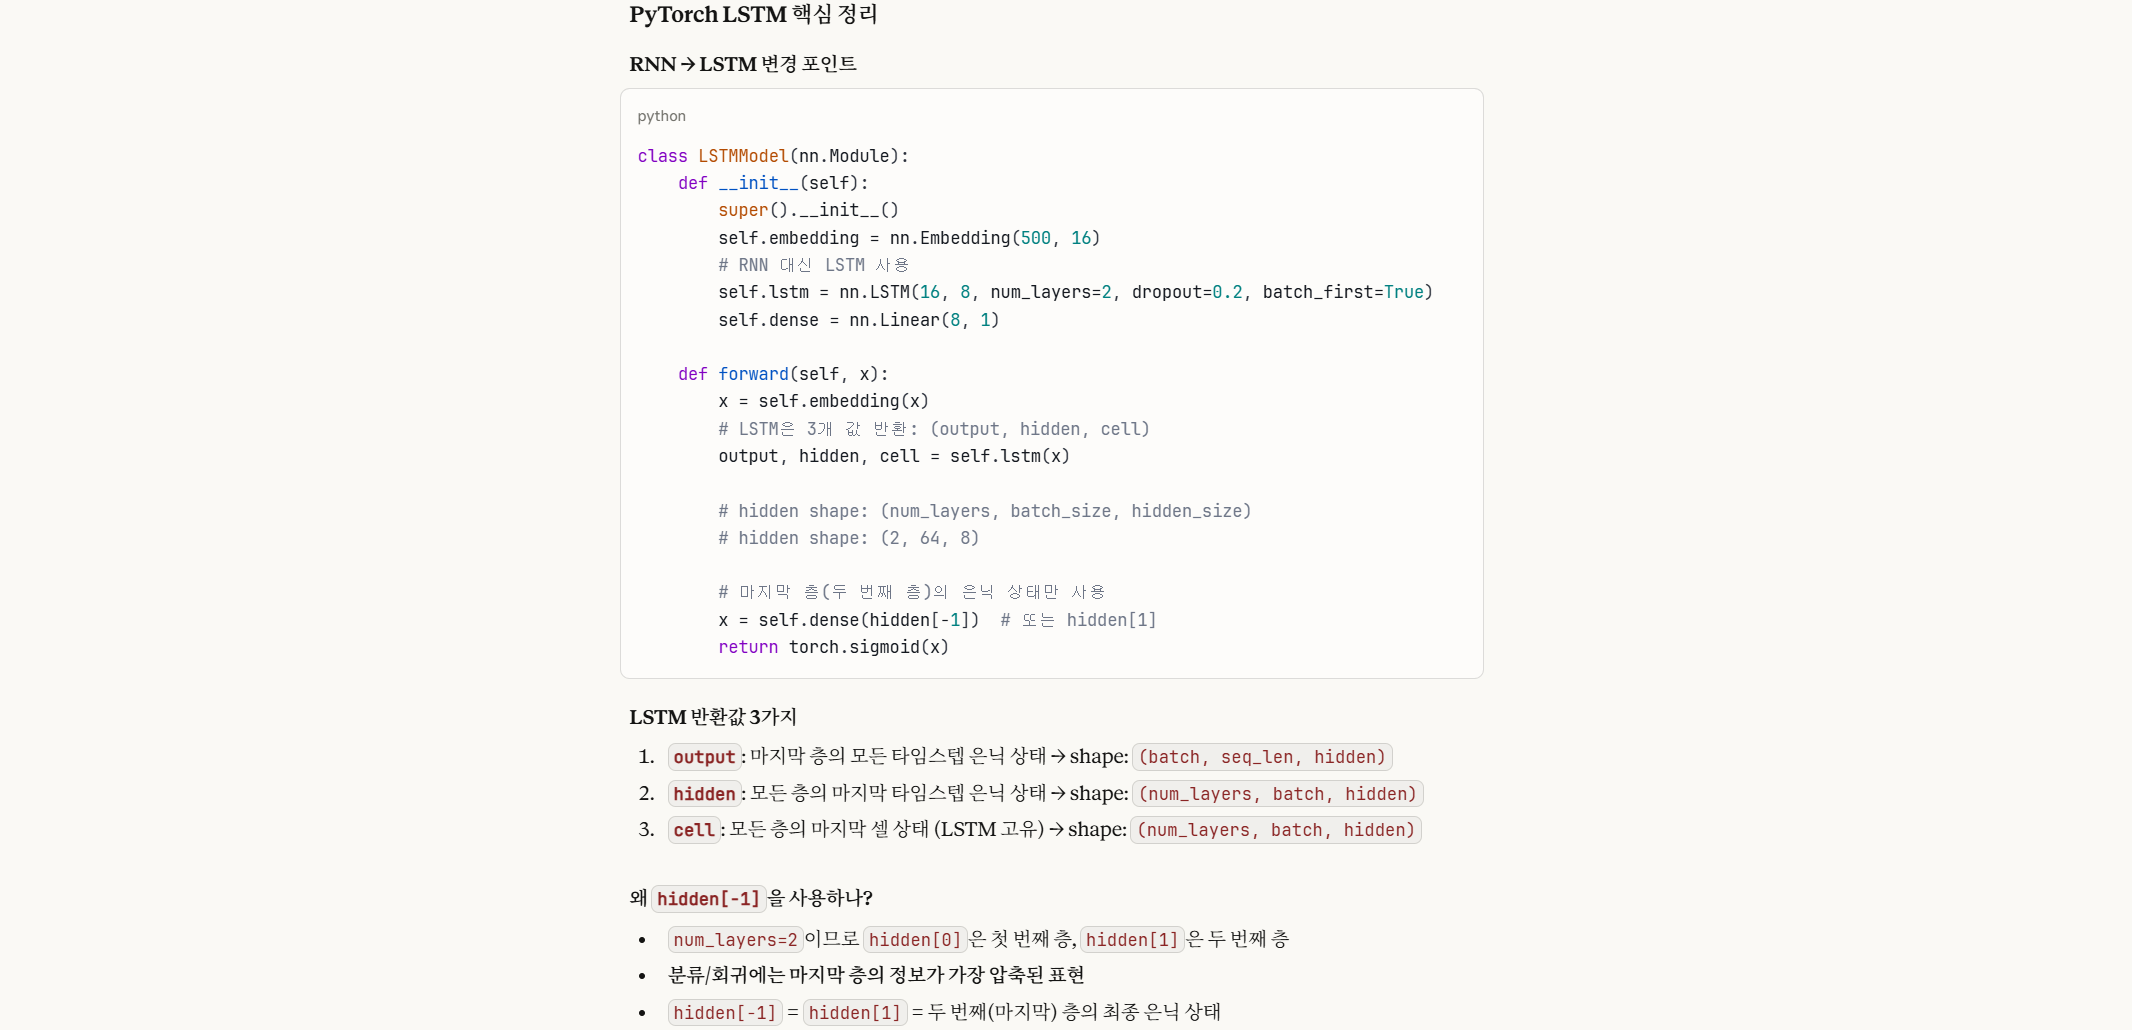

In [54]:
import torch.nn as nn

class IMDBLstm(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(500, 16)
        self.lstm = nn.LSTM(16, 8, batch_first=True, num_layers=2, dropout=0.2)
        self.dense = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.embedding(x)
        # LSTM 반환값: (output, (hidden, cell))
        _, (hidden, _) = self.lstm(x)
        # 마지막 층의 은닉 상태 사용
        outputs = self.dense(hidden[-1])
        return self.sigmoid(outputs)

In [55]:
# 이번에는 Adam 옵티마이저의 학습률로 기본값을 그대로 사용
model = IMDBLstm()
import torch
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters())

train_hist = []
val_hist = []
patience = 2
best_loss = -1
early_stopping_counter = 0
epochs = 100

for epoch in range(epochs):
    # 훈련 모드
    model.train()
    train_loss = 0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs.squeeze(), targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    # 검증 모드
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs.squeeze(), targets)
            val_loss += loss.item()
    
    # 평균 손실 계산
    train_loss = train_loss / len(train_loader)
    val_loss = val_loss / len(val_loader)
    train_hist.append(train_loss)
    val_hist.append(val_loss)
    
    print(f"에포크: {epoch+1}, 훈련 손실: {train_loss:.4f}, 검증 손실: {val_loss:.4f}")
    
    # 조기 종료 로직
    if best_loss == -1 or val_loss < best_loss:
        best_loss = val_loss
        early_stopping_counter = 0
        torch.save(model.state_dict(), 'best_2lstm_model.pt')
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= patience:
            print(f"{epoch+1}번째 에포크에서 조기 종료되었습니다.")
            break

에포크: 1, 훈련 손실: 0.6849, 검증 손실: 0.6523
에포크: 2, 훈련 손실: 0.6344, 검증 손실: 0.6143
에포크: 3, 훈련 손실: 0.6072, 검증 손실: 0.5945
에포크: 4, 훈련 손실: 0.5804, 검증 손실: 0.6207
에포크: 5, 훈련 손실: 0.5650, 검증 손실: 0.5606
에포크: 6, 훈련 손실: 0.5474, 검증 손실: 0.5552
에포크: 7, 훈련 손실: 0.5473, 검증 손실: 0.5444
에포크: 8, 훈련 손실: 0.5176, 검증 손실: 0.5287
에포크: 9, 훈련 손실: 0.5049, 검증 손실: 0.5230
에포크: 10, 훈련 손실: 0.5005, 검증 손실: 0.5173
에포크: 11, 훈련 손실: 0.4960, 검증 손실: 0.5077
에포크: 12, 훈련 손실: 0.4843, 검증 손실: 0.4999
에포크: 13, 훈련 손실: 0.4746, 검증 손실: 0.5000
에포크: 14, 훈련 손실: 0.4665, 검증 손실: 0.5107
14번째 에포크에서 조기 종료되었습니다.


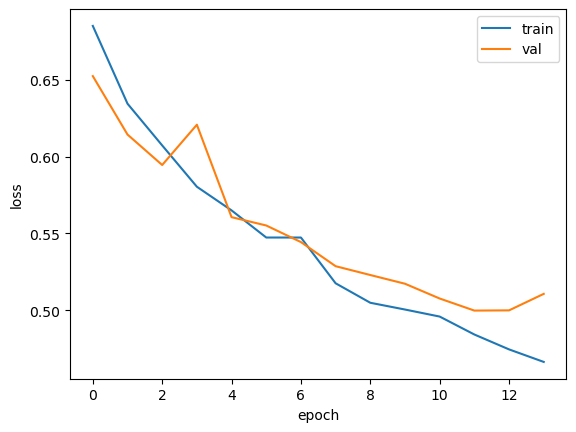

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_hist, label='train')
plt.plot(val_hist, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

# 훈련 손실과 검증 손실이 어느정도 간격을 유지하면서 감소하다가, 12~13번째 에포크 이후부터 두 값의차이가 크게 벌어지는 것을 확인
# 과대적합이 발생하기 전에 적절하게 훈련이 멈춘 것 같습니다

In [ ]:
# best_21stm_model.pt 파일을 로드하여 검증 세트에 대한 정확도 확인

model.load_state_dict(torch.load('best_2lstm_model.pt', weights_only=True))
model.eval()

corrects = 0
with torch.no_grad():
    for inputs, targets in val_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        predicts = outputs > 0.5
        corrects += (predicts.squeeze() == targets).sum().item()

accuracy = corrects / len(val_dataset)
print(f"검증 정확도: {accuracy:.4f}")

#⬇️모델을 검증 세트에서 평가한 결과, 약 76%의 정확도

검증 정확도: 0.7630


In [59]:
#‼️최종적으로 테스트 세트에 대한 모델의 성능을 확인

test_seq = pad_sequences(test_input, maxlen=100)
test_seq = torch.tensor(test_seq)
test_target = torch.tensor(test_target, dtype=torch.float32)
test_dataset = TensorDataset(test_seq, test_target)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

model.eval()
corrects = 0
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        predicts = outputs > 0.5
        corrects += (predicts.squeeze() == targets).sum().item()

accuracy = corrects / len(test_dataset)
print(f"테스트 정확도: {accuracy:.4f}")

테스트 정확도: 0.7637
